**Examples from Plant Operating Reports & Case Studies**

| Mine/Project     | CN Dosage (kg/t) | CN Conc (ppm) | Ore Type       | Notes            |
| ---------------- | ---------------- | ------------- | -------------- | ---------------- |
| Lihir            | 0.6–0.8          | \~400         | Sulphide       | High T° leach    |
| Tasiast          | 0.7–1.0          | 250–400       | Mixed          | Ag-rich          |
| Tanami           | 0.5–0.7          | 200–300       | Sulphide       | CIL circuit      |
| KCGM (Super Pit) | 0.3–0.5          | 150–250       | Oxide/Sulphide | CN recirculation |
| Hemlo            | 0.5–0.9          | 200–350       | Sulphide       | Gold-silver feed |


## 📚 Step 0: Import libraries

Load core libraries for data handling, modelling, and visualisation.

In [826]:
import re
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import shap
from scipy.stats import linregress
from tqdm import tqdm
import plotly.graph_objects as go
from datetime import timedelta
from plotly.subplots import make_subplots
from itertools import product
import plotly.express as px
from scipy.optimize import minimize, curve_fit

## 📥 Step 1: Load and clean column names

Import the dataset and standardise column names for consistency.

In [827]:
# Load dataset
df = pd.read_excel("site_leaching_data_upd.xlsx", sheet_name=0)

# Clean column names: strip whitespace and unify format
def clean_column_name(col):
    col = col.strip()
    col = re.sub(r'\s+', '_', col)
    col = re.sub(r'[^\w\d_]', '', col)
    # Remove double underscores
    col = re.sub(r'__+', '_', col)
    # Convert to lowercase
    col = col.lower()
    # Capitablize first letter and each letter after an underscore
    col = col.replace('_', ' ').title().replace(' ', '_')
    return col

df.columns = [clean_column_name(col) for col in df.columns]

## ⚙️ Step 2: Define constants

Set plant configuration, material properties, modelling parameters, and economic assumptions.

In [828]:
# Plant configuration constants
PRELEACH_TANKS = 2           	# number of pre-leaching tanks
CIL_TANKS = 9                 	# number of CIL tanks
PRELEACH_TANK_VOLUE = 1000.0  	# volume of the pre-leaching tanks in m^3
CIL_TANK_VOLUME = 250.0        	# volume of the CIL tanks in m^3
CARBON_CONCENTRATION = 8.0      # concentration of carbon in the CIL tanks in g/L
carbon_mass_g = CARBON_CONCENTRATION * CIL_TANK_VOLUME * 1000
carbon_mass_t = carbon_mass_g / 1e6 # convert to tonnes

# Material characteristics
SOLIDS_DENSITY = 2.70
SOLUTION_DENSITY = 1.00

# Constants for the training & modeling process
random_seed = 13				# random seed for reproducibility
test_sample_size = 0.2			# proportion of data to use for testing
bin_precision = 1				# precision for binning continuous variables

# Cyanide leaching parameters
min_cn_hist = 100 			    # min. CN in ppm for cleansing historicals
max_cn_hist = 1200 				# max. CN in ppm for cleansing historicals

min_cn_thresh = 50	 			# min. CN threshold in ppm for modelling
max_cn_thresh = 600 			# max. CN threshold in ppm for modelling

min_do_thresh = 13.0 			# min DO in ppm for modelling
max_do_thresh = 17.0 			# max DO in ppm for modelling
do_smoothing_window = 45		# smoothing window in days for DO data

# Set CN bounds
cn_lower_bound = 200  			# lower bound for cyanide concentration in ppm in PL 01
cn_upper_bound = 500  			# upper bound for cyanide concentration in ppm in PL 01
penalty_threshold = 550  		# where overdose penalty kicks in
penalty_weight = 0.5     		# USD per excess ppm * t

do_lower_bound = 13.0  			# lower bound for dissolved oxygen in ppm in PL 01
do_upper_bound = 17.0  			# upper bound for dissolved oxygen in ppm in PL 01

# Feed charateristics
ultra_fine_sizing = 50	 		# midpoint for < 75 µm sizing
fine_sizing = 112.5				# midpoint for > 75 µm sizing
coarse_sizing = 175 			# midpoint for > 150 µm sizing

# Performance metric thresholds (used for weekly plotting)
recovery_green = 4				# recovery value delta threshold for green zone in USD per tonne
recovery_orange = 7				# recovery value delta threshold for orange zone in USD per tonne
cn_green = 0.15					# cyanide concentration threshold for green zone as delta % to optimal
cn_orange = 0.30				# cyanide concentration threshold for orange zone as delta % to optimal
do_green = 0.10					# dissolved oxygen concentration threshold for green zone as delta % to optimal
do_orange = 0.35				# dissolved oxygen concentration threshold for orange zone as delta % to optimal

# Economic constants
GOLD_PRICE_USD_PER_G = 89.24
NACN_PRICE_USD_PER_KG = 2.7
DO_PRICE_USD_PER_KG = 0.03 	    # USD per kg per tonne
TROY_OZ_TO_G = 31.1035
PPM_TO_KG_PER_T = 1 / 1_000_000 * 1_000  # convert ppm to kg/t
CN_PENALTY_THRESHOLD = 450      # ppm
CN_PENALTY_WEIGHT = 1.0         # USD per ppm per tonne above threshold

In [829]:
df.columns.tolist()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Leach_Feed_Grade_Au_Gt_Day',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Cil_Feed_Total_Au_Grams',
 'Cn_Conc_Tailing_Ppm',
 'Total_Au_Tailing_Grams',
 'Leach_Feed_Gt_150Μm_Day',
 'Leach_Feed_Gt_75Μm_Day',
 'Leach_Feed_Lt_75Μm_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxyge

## 🧹 Step 3: Clean and engineer features

Prepare key fields for modelling by cleansing inputs, imputing missing values, and calculating derived features like solution mass, CN dosage, DO smoothing, particle size, and recovery.

In [830]:
# Define a function to calculate the solution mass
def calc_solution_mass(percent_solids, tonnes_processed):
    """
    Calculate the mass of the solution in kg based on the percentage of solids and tonnes processed.
    :param percent_solids: Percentage of solids in the slurry.
    :param tonnes_processed: Tonnes of material processed.
    :return: Mass of the solution in kg.
    """
    solids_fraction = percent_solids / 100
    slurry_mass_kg = tonnes_processed * 1000 / solids_fraction
    return slurry_mass_kg * (1 - solids_fraction)

# --- Calculate residence time across leach circuit ---
df["Residence_Time"] = (PRELEACH_TANKS * PRELEACH_TANK_VOLUE + 
                           CIL_TANKS * CIL_TANK_VOLUME) / df["Leach_Feed_Throughput_M3Hr"]

# --- Calculate daily throughput in tonnes ---
# Convert m³/day to tonnes/day using density and solids fraction
df["Tonnes_Processed"] = (
    df["Leach_Feed_Throughput_M3Day"] * (df["Percentsolids"] / 100) * SOLIDS_DENSITY
)

# --- Calculate CN dosage into leaching circuit ---	
# Fill NaNs with 0 for safe comparison
ppm_tank_1 = df["Cyanide_Profile_Ppm_Leach_Tank_1"].fillna(0).where(
lambda x: (x >= min_cn_hist) & (x <= max_cn_hist), 0
)
ppm_tank_2 = df["Cyanide_Profile_Ppm_Leach_Tank_2"].fillna(0).where(
    lambda x: (x >= min_cn_hist) & (x <= max_cn_hist), 0
)

# Flags indicating which pre-leach tank is receiving CN
df["Leach_Cn_Adds_To_Tank_1"] = ppm_tank_1 > ppm_tank_2
df["Leach_Cn_Adds_To_Tank_2"] = ~df["Leach_Cn_Adds_To_Tank_1"]

# Actual ppm value from the pre-leach tank identified as dosing
df["Leach_Cn_Adds_ppm"] = np.where(df["Leach_Cn_Adds_To_Tank_1"], ppm_tank_1, ppm_tank_2)


# % solids to fractional solids
df["Solids_Fraction"] = df["Percentsolids"] / 100
df["Liquid_Fraction"] = 1 - df["Solids_Fraction"]

# Wet mass of slurry (kg)
df["Slurry_Mass_Kg"] = df["Daily_Milledtreated_Tons"] * 1000 / df["Solids_Fraction"]

# Liquid mass in slurry (assuming water ~1kg/L)
df["Solution_Mass_Kg"] = df["Slurry_Mass_Kg"] * df["Liquid_Fraction"]

df["NaCN_Used_Kg"] = df["Leach_Cn_Adds_ppm"] * df["Solution_Mass_Kg"] / 1e6

df['CN_Kg_T'] = df['NaCN_Used_Kg'] / df['Daily_Milledtreated_Tons']

# --- Clean and impute dissolved oxygen (DO) profile ---
o2_col = "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01"

# Replace zero with NaN
df[o2_col] = df[o2_col].replace(0.0, np.nan)

# Impute using a rolling median (or fallback to overall median)
df[o2_col + "_Imputed"] = df[o2_col].fillna(
    df[o2_col].rolling(window=3, min_periods=1, center=True).median()
)

df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth"] = (
    df["Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Imputed"]
    .rolling(window=do_smoothing_window, min_periods=1, center=True)
    .mean()
)

# Fallback for any remaining NaNs (start/end of window)
df[o2_col + "_Imputed"] = df[o2_col + "_Imputed"].fillna(df[o2_col].median())

# --- Standardise feed grade and throughput column names ---
df["Leach_Feed_Grade_Au_Gt"] = df["Leach_Feed_Grade_Au_Gt_Day"]

# Standardise particle size fields
df = df.rename(columns={
    "Leach_Feed_Gt_150Μm_Day": "Leach_Feed_Gt_150um_Day",
    "Leach_Feed_Gt_75Μm_Day": "Leach_Feed_Gt_75um_Day",
    "Leach_Feed_Lt_75Μm_Day": "Leach_Feed_Lt_75um_Day"
})

# Ensure datetime is parsed
df["Date"] = pd.to_datetime(df["Date"])


# --- Create Interaction terms ---
size_sum = (
        df["Leach_Feed_Lt_75um_Day"] +
        df["Leach_Feed_Gt_75um_Day"] +
        df["Leach_Feed_Gt_150um_Day"]
    )
df["Fines_Fraction"] = df["Leach_Feed_Lt_75um_Day"] / size_sum.replace(0, np.nan)
df["Grade_x_Fines"] = df["Leach_Feed_Grade_Au_Gt_Day"] * df["Fines_Fraction"]

ultra_fine_field = "Leach_Feed_Lt_75um_Day"
fine_field = "Leach_Feed_Gt_75um_Day"
coarse_field = "Leach_Feed_Gt_150um_Day"


# Calculate Effective Particle Size (um)
def get_effective_particle_size(row, ultra_field, fine_field, coarse_field,
                                ultra_size, fine_size, coarse_size):
    total = row[ultra_field] + row[fine_field] + row[coarse_field]
    if total == 0:
        return np.nan
    weighted_d = (
        row[ultra_field] * ultra_size +
        row[fine_field] * fine_size +
        row[coarse_field] * coarse_size
    ) / total
    return weighted_d

df["Effective_Particle_Size_um"] = df.apply(
    lambda row: get_effective_particle_size(
        row,
        ultra_fine_field,
        fine_field,
        coarse_field,
        ultra_fine_sizing,
        fine_sizing,
        coarse_sizing
    ),
    axis=1
)

# Calculate Au Recovery %
df["Actual_Recovery"] = (
    (df["Cil_Feed_Total_Au_Grams"] - df["Total_Au_Tailing_Grams"])
    / df["Cil_Feed_Total_Au_Grams"]
) * 100

# --- Rename essential columns for clarity ---
df = df.rename(columns={
    "Cil_Feed_Total_Au_Grams": "Au_Feed_Grams",
    "Total_Au_Tailing_Grams": "Au_Tailings_Grams",
    "Cn_Conc_Tailing_Ppm": "CN_Tailings_Concentration",
    "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01_Smooth": "Dissolved_Oxygen_PL_01",
    "Effective_Particle_Size_um": "Particle_Size",
    "Leach_Cn_Adds_ppm": "CN_Concentration_PL_01",
    "Leach_Feed_Grade_Au_Gt_Day": "Au_Grade",
    "Daily_Milledtreated_Tons": "Leach_Solids"
})

## 📈 Step 4: Explore variable interactions

Visualise recovery trends across CN, DO, particle size, grade, and other key drivers.

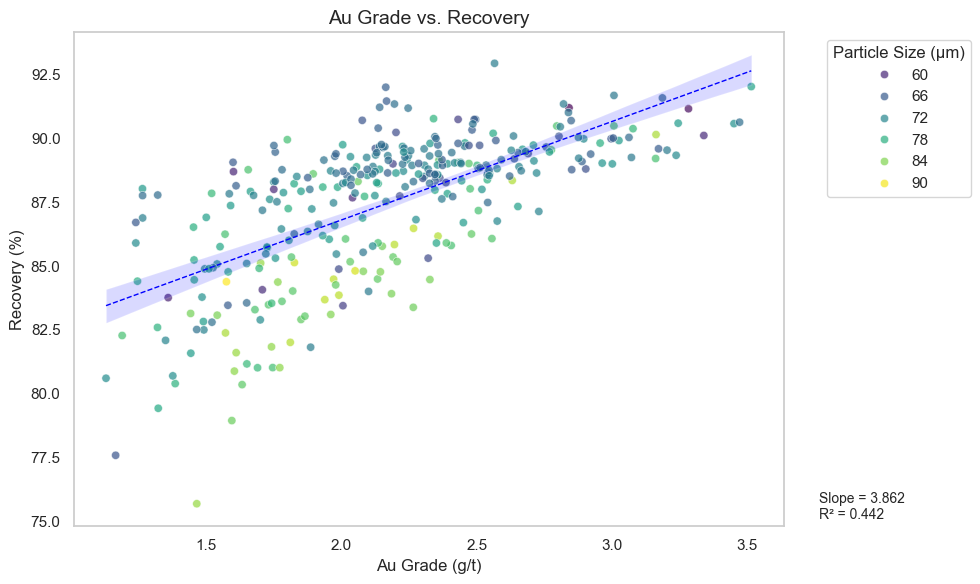

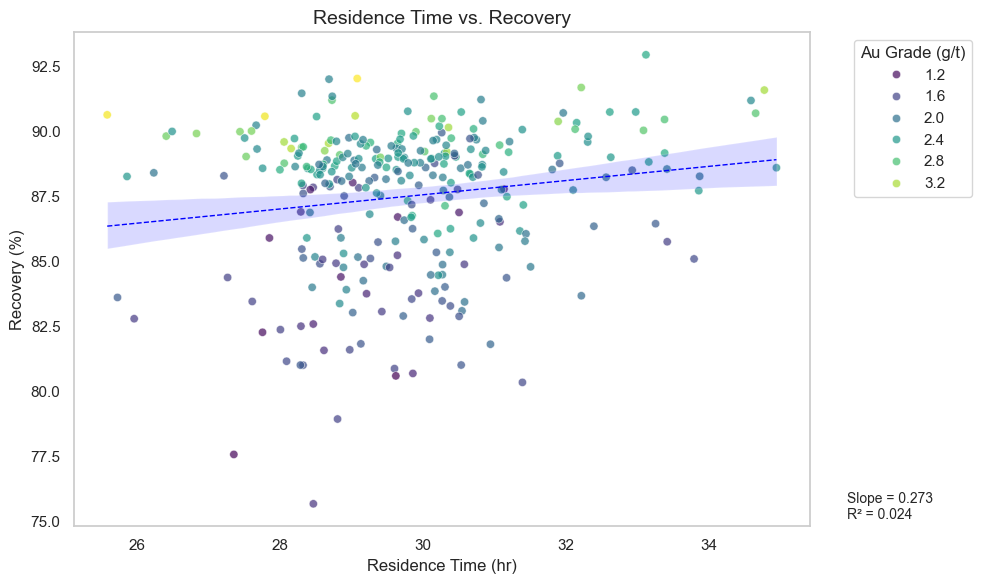

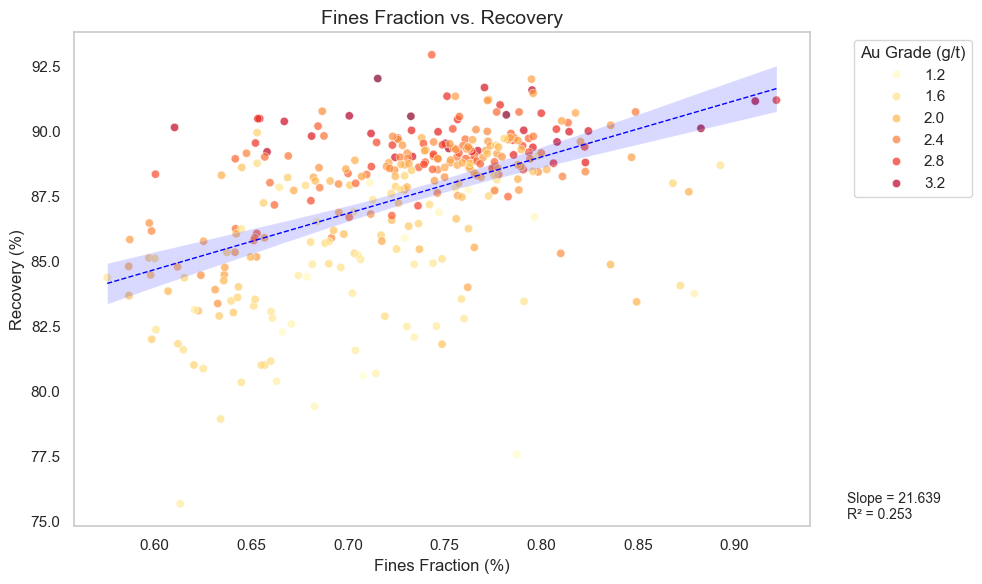

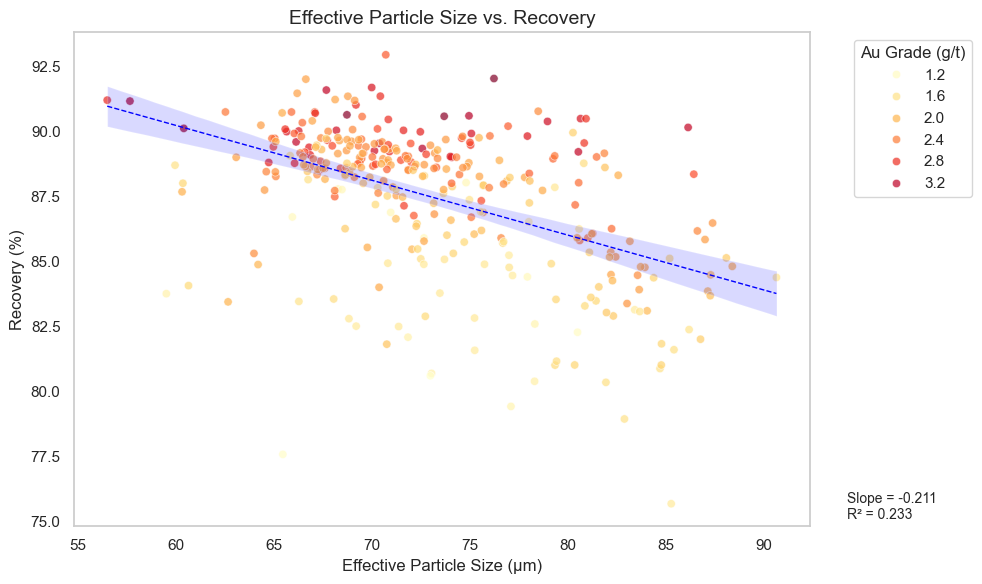

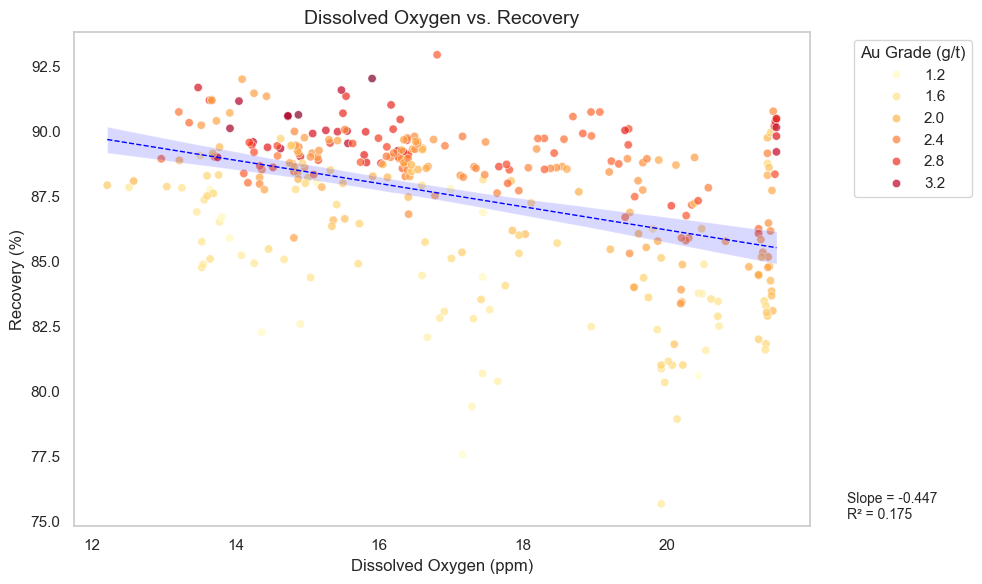

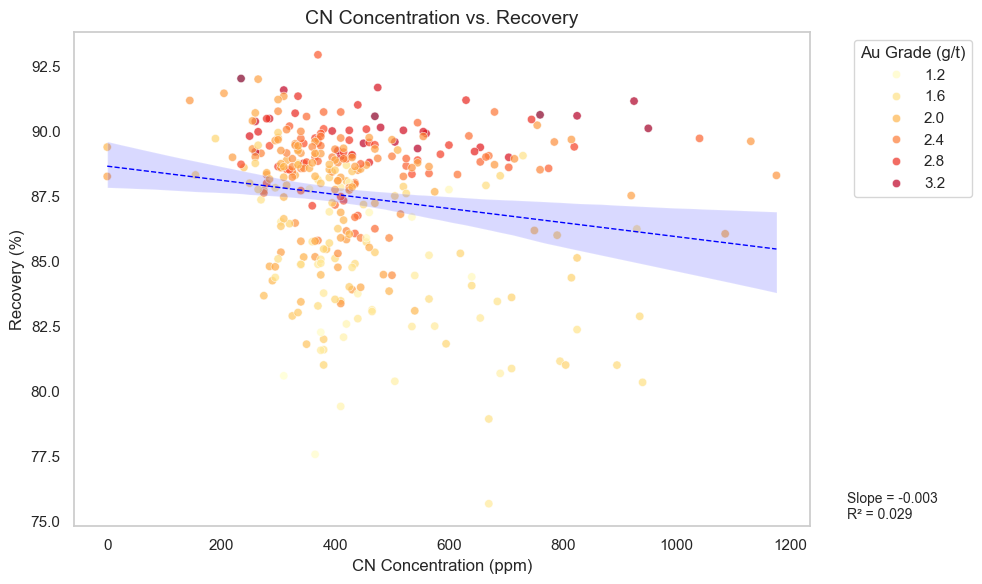

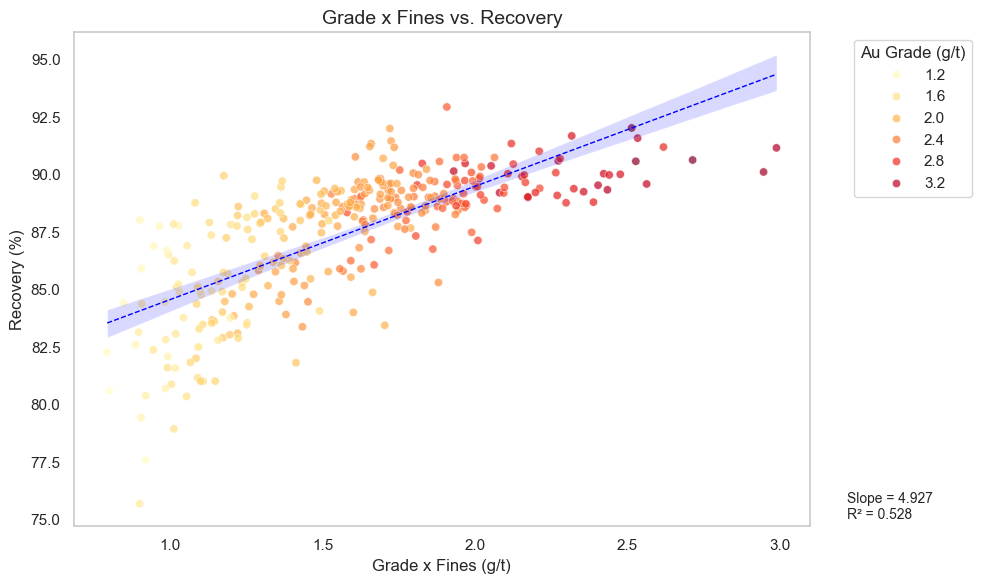

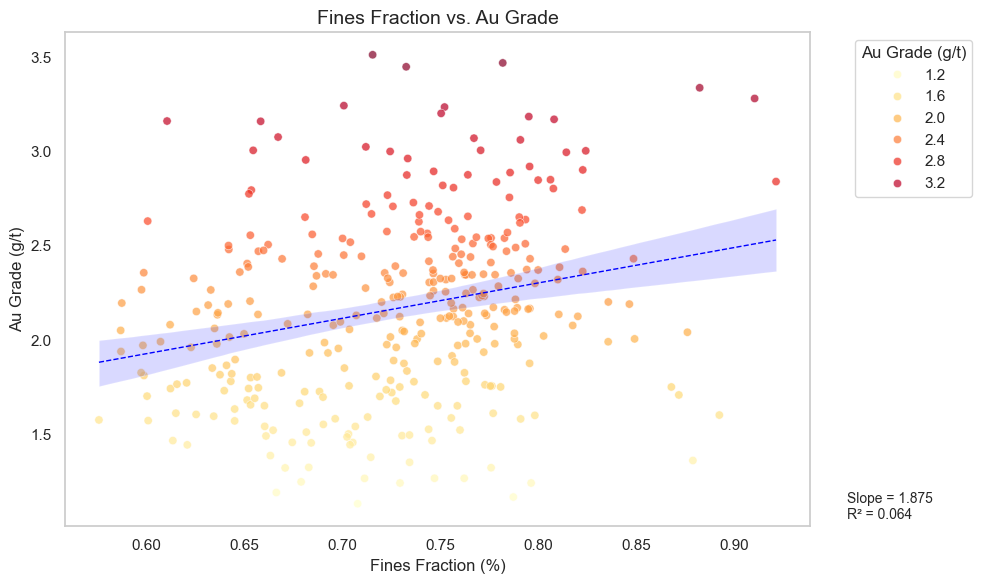

In [831]:
# Define the target variable for modelling
target = "Actual_Recovery"

# Plot scatter plot for interaction between Effective Particle Size and Au Recovery
def scatter_plot_trend_hue(df, x_col, y_col, hue_col="Au_Grade", hue_title="Au Grade (g/t)",
                           title: str = "Scatter Plot with Regression Line",
                           xlabel: str = "X", ylabel: str = "Y", palette: str = "YlOrRd"):
    """
    Plot scatter plot with regression line and show regression slope as a text box.
    """
    # Calculate regression line
    slope, intercept, r_value, p_value, std_err = linregress(df[x_col], df[y_col])
    reg_text = f"Slope = {slope:.3f}\nR² = {r_value**2:.3f}"

    # Create plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=x_col, y=y_col, data=df,
                    hue=hue_col, palette=palette, alpha=0.7)
    sns.regplot(x=x_col, y=y_col, data=df,
                scatter=False, color='blue', line_kws={"linestyle": "--", "linewidth": 1})

    # Add regression info box
    plt.text(1.05, 0.07, reg_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round',
                                                    facecolor='white', alpha=0.6))

    # Final plot styling
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title=hue_title, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# Call the function to plot Effective Particle Size vs. Recovery
scatter_plot_trend_hue(df, "Au_Grade", target, hue_col="Particle_Size",
                       title="Au Grade vs. Recovery", hue_title="Particle Size (µm)",
                       xlabel="Au Grade (g/t)", ylabel="Recovery (%)", palette="viridis")

# Filter extreme residence times for plotting
df_res = df.copy()
df_res = df_res[(df_res["Residence_Time"] >= 25) & (df_res["Residence_Time"] <= 35)]

scatter_plot_trend_hue(df_res, "Residence_Time", target, hue_col="Au_Grade",
                       title="Residence Time vs. Recovery", hue_title="Au Grade (g/t)",
                       xlabel="Residence Time (hr)", ylabel="Recovery (%)", palette="viridis")

scatter_plot_trend_hue(df, "Fines_Fraction", target, hue_col="Au_Grade",
                       title="Fines Fraction vs. Recovery",
                       xlabel="Fines Fraction (%)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Particle_Size", target, hue_col="Au_Grade",
                       title="Effective Particle Size vs. Recovery",
                       xlabel="Effective Particle Size (µm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Dissolved_Oxygen_PL_01", target, hue_col="Au_Grade",
                       title="Dissolved Oxygen vs. Recovery",
                       xlabel="Dissolved Oxygen (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "CN_Concentration_PL_01", target, hue_col="Au_Grade",
                       title="CN Concentration vs. Recovery",
                       xlabel="CN Concentration (ppm)", ylabel="Recovery (%)")

scatter_plot_trend_hue(df, "Grade_x_Fines", target, hue_col="Au_Grade",
                       title="Grade x Fines vs. Recovery",
                       xlabel="Grade x Fines (g/t)", ylabel="Recovery (%)")

# Plot Fines v Grade
scatter_plot_trend_hue(df, "Fines_Fraction", "Au_Grade",
                          xlabel="Fines Fraction (%)", ylabel="Au Grade (g/t)",
                          title="Fines Fraction vs. Au Grade")

## 🔬 Step 5: Build and optimise kinetic model

Estimate gold recovery using a simplified kinetic model and identify optimal CN and DO concentrations to maximise net value.

### 🧪 Step 5.1: Define kinetic recovery function

Implement a simplified kinetic leaching model based on Lima & Hodouin (2003). This function uses CN and DO concentrations, particle size, and a liberation model to estimate recovery.

In [832]:
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
                          gold_locked_fraction=0.1,
                          k_base=0.005,             # Reaction rate constant
                          cn_exponent=0.8,          # CN concentration exponent
                          do_exponent=0.6,          # DO concentration exponent
                          liberation_factor=1.8):   # Sensitivity to particle size
    """
    Estimate gold recovery (%) using an adjusted kinetic model (Lima & Hodouin, 2003).
    """

    # Ensure safe minimum values
    cn_ppm = max(cn_ppm, 1)
    do_ppm = max(do_ppm, 0.1)
    particle_size_um = max(particle_size_um, 1)

    # Liberation model: smaller particles yield more liberated gold
    liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))

    # Recovery kinetics
    k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
    recovery_pct = liberation * (1 - np.exp(-k_effective))

    return recovery_pct * 100


#### Test Cell

In [833]:
# --- Quick test on 10 sample rows ---
sample_df = df.head(10).copy()

for _, row in sample_df.iterrows():
    cn = row['CN_Concentration_PL_01']
    do = row['Dissolved_Oxygen_PL_01']
    grade = row['Au_Grade']
    psd = row['Particle_Size']
    recovery = calc_recovery_kinetic(cn, do, grade, psd)
    actual = row['Actual_Recovery']
    error = recovery - actual

    print(f"Kinetic Recovery: {recovery:.2f}% | Actual: {actual:.2f}% | Error: {error:.2f}%")


Kinetic Recovery: 96.87% | Actual: 84.49% | Error: 12.38%
Kinetic Recovery: 96.73% | Actual: 86.26% | Error: 10.47%
Kinetic Recovery: 96.38% | Actual: 86.08% | Error: 10.30%
Kinetic Recovery: 96.94% | Actual: 84.47% | Error: 12.47%
Kinetic Recovery: 95.29% | Actual: 82.01% | Error: 13.28%
Kinetic Recovery: 95.17% | Actual: 84.48% | Error: 10.68%
Kinetic Recovery: 95.96% | Actual: 85.84% | Error: 10.12%
Kinetic Recovery: 93.41% | Actual: 85.35% | Error: 8.05%
Kinetic Recovery: 96.03% | Actual: 83.48% | Error: 12.55%
Kinetic Recovery: 95.33% | Actual: 83.29% | Error: 12.04%


### 🔁 Step 5.2: Optimise CN and DO bands

Sweep CN and DO values to find the combination that maximises recovery and economic return.

In [834]:
# --- Define grid parameters ---
cn_step = 5  	                # ppm per step
do_step = 1  	                # ppm per step

# --- Sweep ranges for CN and DO ---
cn_range = np.arange(10, 300, 20)
do_range = np.arange(10, 20, 10)
# cn_range = np.linspace(min_cn_thresh, max_cn_conc, (int((max_cn_conc - max_cn_thresh) / cn_step) + 1))
# do_range = np.linspace(min_do_conc, max_do_conc, (int((max_do_conc - min_do_conc) / do_step) + 1))

# --- Band parameters ---
cn_band_width = 0.15  # ±15%
do_band_width = 0.10  # ±10%

# --- Placeholder economic recovery model (TO BE REPLACED LATER WITH TUNED KINETIC MODEL) ---
def kinetic_model_recovery(grade_x_fines, particle_size, cn_ppm, do_ppm):
    base_recovery = 50 + 0.25 * grade_x_fines
    cn_effect = 25 * (1 - np.exp(-0.005 * cn_ppm))
    do_effect = 15 * (1 - np.exp(-0.2 * do_ppm))
    size_penalty = -10 * (particle_size / 150)
    return np.clip(base_recovery + cn_effect + do_effect + size_penalty, 0, 100)

# --- Optimise CN and DO for each row ---
results = []

for _, row in df.iterrows():
    grade_x_fines = row.get("Grade_x_Fines", np.nan)
    psd = row.get("Particle_Size", np.nan)

    best_value = -np.inf
    optimal_cn, optimal_do, optimal_recovery = None, None, None

    for cn in cn_range:
        for do in do_range:
            recovery = kinetic_model_recovery(grade_x_fines, psd, cn, do)
            gold_revenue = recovery / 100 * grade_x_fines * GOLD_PRICE_USD_PER_G
            nacn_cost = cn * PPM_TO_KG_PER_T * NACN_PRICE_USD_PER_KG
            do_cost = do * DO_PRICE_USD_PER_KG
            net_value = gold_revenue - nacn_cost - do_cost

            if net_value > best_value:
                best_value = net_value
                optimal_cn, optimal_do = cn, do
                optimal_recovery = recovery

    # Define upper/lower bands
    cn_low = optimal_cn * (1 - cn_band_width)
    cn_high = optimal_cn * (1 + cn_band_width)
    do_low = optimal_do * (1 - do_band_width)
    do_high = optimal_do * (1 + do_band_width)

    results.append({
        "Optimal_CN_ppm": round(optimal_cn, 1),
        "CN_Low_ppm": round(cn_low, 1),
        "CN_High_ppm": round(cn_high, 1),
        "Optimal_DO_ppm": round(optimal_do, 2),
        "DO_Low_ppm": round(do_low, 2),
        "DO_High_ppm": round(do_high, 2),
        "Predicted_Recovery_pct": round(optimal_recovery, 2),
        "Net_Value_USD_t": round(best_value, 2)
    })

# --- Merge optimisation results ---
# Convert results into a DataFrame
df_optimised = pd.DataFrame(results)

# Make sure index alignment matches
df_optimised.index = df.index  # optional if you've dropped/reset the index above

df = df.copy()

# Join all new columns to the original df
df = pd.concat([df, df_optimised], axis=1)

df["Kinetic_Recovery"] = df["Predicted_Recovery_pct"]

# --- Display preview ---
df.head(10)

,Date,Leach_Feed_Throughput_M3Hr,Leach_Feed_Throughput_M3Day,Percentsolids,Leach_Feed_Grade_Au_Gt_Ds,Leach_Feed_Grade_Au_Gt_Ns,Au_Grade,Leach_Feed_Grade_Ag_Gt_Ds,Leach_Feed_Grade_Ag_Gt_Ns,Leach_Feed_Grade_Ag_Gt_Day,...,Actual_Recovery,Optimal_CN_ppm,CN_Low_ppm,CN_High_ppm,Optimal_DO_ppm,DO_Low_ppm,DO_High_ppm,Predicted_Recovery_pct,Net_Value_USD_t,Kinetic_Recovery
0,2024-06-01,140.387445,3369.298687,51.041667,2.08,2.13,2.134255,7.80,5.99,6.895,...,84.492989,290,246.5,333.5,10,9.0,11.0,76.97,92.16,76.97
1,2024-06-02,139.864505,3356.748120,51.083333,2.43,2.53,2.480958,6.93,6.98,6.955,...,86.257017,290,246.5,333.5,10,9.0,11.0,77.02,108.39,77.02
2,2024-06-03,140.687229,3376.493498,51.083333,2.28,2.83,2.556436,5.22,5.31,5.265,...,86.076024,290,246.5,333.5,10,9.0,11.0,77.11,113.77,77.11
3,2024-06-04,140.645957,3375.502965,51.166667,2.19,2.46,2.327386,5.57,7.01,6.290,...,84.470492,290,246.5,333.5,10,9.0,11.0,76.90,98.58,76.90
4,2024-06-05,141.223079,3389.353889,51.083333,2.07,1.55,1.811915,5.15,4.97,5.060,...,82.010329,290,246.5,333.5,10,9.0,11.0,76.59,73.05,76.59
5,2024-06-06,141.145751,3387.498023,51.125000,1.86,2.08,1.971912,3.60,5.26,4.430,...,84.484298,290,246.5,333.5,10,9.0,11.0,76.58,79.51,76.58
6,2024-06-07,141.590348,3398.168358,51.041667,2.07,2.32,2.196439,4.79,6.72,5.755,...,85.842574,290,246.5,333.5,10,9.0,11.0,76.63,87.12,76.63
7,2024-06-08,139.903548,3217.781613,51.166667,2.49,1.89,2.191432,5.65,8.43,7.040,...,85.354122,290,246.5,333.5,10,9.0,11.0,76.98,95.51,76.98
8,2024-06-09,140.400391,3369.609374,51.083333,1.69,1.77,1.731436,4.74,5.43,5.085,...,83.484372,290,246.5,333.5,10,9.0,11.0,76.95,74.97,76.95
9,2024-06-10,139.871247,3356.909918,51.291667,1.60,1.76,1.681424,3.28,5.12,4.200,...,83.290975,290,246.5,333.5,10,9.0,11.0,76.99,74.16,76.99


## 🧪 Step 6: Analyse Cyanide Consumption and Gold Dissolution
This step calculates daily and monthly cyanide usage across leach and CIL tanks, estimates tailings losses, and compares original vs gold-weighted CN consumption. It also tracks dissolved gold by tank and aggregates usage trends across time.

### 🔬 6.1 Estimate Daily CN Consumption and Gold Dissolution
Estimate cyanide mass, residence time, and consumption per tank using tank volume and CN profiles. Also calculates gold dissolved via leach (incremental GPT × volume) and CIL (carbon loading × carbon mass). Outputs per-tank daily CN and Au dissolved data.

In [835]:
def calculate_gold_dissolved_per_tank(row, dry_tonnes, cil_tank_volume_m3=CIL_TANK_VOLUME):
    """
    Estimates gold dissolved in each tank (grams), using:
    - Incremental dissolved gold (g/t × dry tonnes) for Leach tanks
    - Carbon loading (g/t carbon × calculated carbon mass) for CIL tanks
    """

    # Tank order
    leach_tanks = ["Leach_Tank_01", "Leach_Tank_02"]
    cil_tanks = [f"Cil_Tank_{i:02}" for i in range(1, 10)]
    tank_order = leach_tanks + cil_tanks

    # Map cumulative dissolved gold columns to tanks
    gpt_map = {
        "Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_01": "Leach_Tank_01",
        "Dissolved_Gold_Metal_Profile_G_Milled_Tons_Leach_Tank_02": "Leach_Tank_02",
        **{
            f"Dissolved_Gold_Metal_Profile_G_Milled_Tons_Cil_Tank_0{i}": f"Cil_Tank_{i:02}"
            for i in range(1, 10)
        }
    }

    # Get gpt series and calculate incremental gold dissolved
    gpt_series = pd.Series({tank: row[col] for col, tank in gpt_map.items()})
    incremental_gpt = gpt_series.diff().fillna(gpt_series.iloc[0])

    # --- Leach Tanks: Gold dissolved = incremental g/t × dry tonnes ---
    gold_dissolved_leach = pd.Series({
        tank: max(incremental_gpt[tank] * dry_tonnes, 0)
        for tank in leach_tanks
    })

    # --- CIL Tanks: Gold on carbon = carbon concentration × volume × loading ---
    carbon_conc_map = {
        f"Carbon_Concentration_Profile_Gl_Cil_Tank_0{i}": f"Cil_Tank_{i:02}"
        for i in range(1, 10)
    }

    loading_map = {
        f"Gold_Carbon_Loadings_Profile_Gt_Of_Carbon_Cil_Tank_0{i}": f"Cil_Tank_{i:02}"
        for i in range(1, 10)
    }

    volume_l = cil_tank_volume_m3 * 1000  # m³ to litres
    carbon_mass_tonnes = {
        tank: row[col] * volume_l / 1_000_000
        for col, tank in carbon_conc_map.items()
    }

    gold_on_carbon = pd.Series({
        tank: row[col] * carbon_mass_tonnes.get(tank, 0)
        for col, tank in loading_map.items()
    }).reindex(cil_tanks).fillna(0)

    # Combine all tanks
    all_dissolved = pd.concat([gold_dissolved_leach, gold_on_carbon]).reindex(tank_order)

    return pd.DataFrame({
        "Tank": tank_order,
        "Gold_Dissolved_g": all_dissolved.values
    })



def estimate_daily_cyanide_consumption(
    df_row,
    tp_field: str = "Leach_Feed_Throughput_M3Day",
    cn_tail_ppm: float = None,
    solution_density: float = SOLUTION_DENSITY,
    solids_density: float = SOLIDS_DENSITY,
    use_gold_weighting: bool = False
):
    """
    Estimates CN mass and consumption per tank for a single row.

    Returns:
    - df_tanks: DataFrame per tank with CN and optional gold-based reweighting
    - cn_loss_to_tail_kg_per_day: CN lost to tailings
    - dry_tonnes: Tonnes of dry solids
    - slurry_density: Bulk slurry density
    - estimated_added_kg: Sum of CN consumed across all tanks
    """

    # --- Define tank metadata ---
    tank_info = {
        "Leach_Tank_01": {"col": "CN_Concentration_PL_01", "volume": PRELEACH_TANK_VOLUE},
        "Leach_Tank_02": {"col": "Cyanide_Profile_Ppm_Leach_Tank_2", "volume": PRELEACH_TANK_VOLUE},
        **{
            f"Cil_Tank_{i:02}": {
                "col": f"Cyanide_Profile_Ppm_Cil_Tank_0{i}",
                "volume": CIL_TANK_VOLUME
            } for i in range(1, 10)
        }
    }

    # --- Throughput and densities ---
    tp_m3_per_day = df_row[tp_field]
    flow_m3_per_hr = tp_m3_per_day / 24
    solids_fraction = df_row["Percentsolids"] / 100

    slurry_density = 1 / ((solids_fraction / solids_density) + ((1 - solids_fraction) / solution_density))
    wet_tonnes = tp_m3_per_day * slurry_density
    dry_tonnes = wet_tonnes * solids_fraction

    # --- CN per tank ---
    tank_data = []
    for tank, meta in tank_info.items():
        cn_ppm = df_row[meta["col"]]
        volume = meta["volume"]
        residence_time_hr = volume / flow_m3_per_hr
        cn_mass_kg = cn_ppm * volume / 1000  # Convert ppm × m³ → kg

        tank_data.append({
            "Tank": tank,
            "CN_ppm": cn_ppm,
            "Tank_Volume_m3": volume,
            "Residence_Time_hr": residence_time_hr,
            "CN_Mass_kg": cn_mass_kg
        })

    df_tanks = pd.DataFrame(tank_data)

    # --- Mass difference consumption logic ---
    df_tanks["CN_Consumed_kg"] = df_tanks["CN_Mass_kg"] - df_tanks["CN_Mass_kg"].shift(-1)

    # --- CN tailings loss ---
    if cn_tail_ppm is None:
        cn_tail_ppm = df_row["CN_Tailings_Concentration"]

    cn_loss_to_tail_kg_per_day = cn_tail_ppm * tp_m3_per_day / 1000
    last_idx = df_tanks.index[-1]
    df_tanks.loc[last_idx, "CN_Consumed_kg"] = df_tanks.loc[last_idx, "CN_Mass_kg"] - cn_loss_to_tail_kg_per_day
    df_tanks["CN_Consumed_kg"] = df_tanks["CN_Consumed_kg"].clip(lower=0)

    # --- Optional: Gold-based reweighting ---
    if use_gold_weighting:
        gold_df = calculate_gold_dissolved_per_tank(df_row, dry_tonnes)
        total_gold = gold_df["Gold_Dissolved_g"].sum()

        gold_df["Weight"] = gold_df["Gold_Dissolved_g"] / total_gold if total_gold > 0 else 0
        df_tanks = df_tanks.merge(gold_df[["Tank", "Gold_Dissolved_g", "Weight"]], on="Tank", how="left")
        df_tanks["Weight"] = df_tanks["Weight"].fillna(0)
        total_cn = df_tanks["CN_Consumed_kg"].sum()
        df_tanks["CN_Consumed_Adjusted_kg"] = df_tanks["Weight"] * total_cn
    else:
        df_tanks["CN_Consumed_Adjusted_kg"] = df_tanks["CN_Consumed_kg"]

    estimated_added_kg = df_tanks["CN_Consumed_Adjusted_kg"].sum()

    return df_tanks, cn_loss_to_tail_kg_per_day, dry_tonnes, slurry_density, estimated_added_kg



summary_records = []
tank_records = []

for _, row in df.iterrows():
    tanks, cn_loss, dry_tonnes, slurry_density, estimated_added_kg = estimate_daily_cyanide_consumption(row,
                                                            use_gold_weighting=True)

    # Prepare per-tank gold and CN data as flat dictionary
    gold_dissolved = {}
    nacn_used = {}
    res_time = {}

    for _, tank_row in tanks.iterrows():
        tank = tank_row["Tank"]
        
        # Format tank names for column keys
        suffix = tank.replace("Leach_Tank_", "Leach_Tank_").replace("Cil_Tank_", "Cil_Tank_")

        gold_col = f"Dissolved_Gold_{suffix}_g"
        nacn_col = f"NaCN_Used_{suffix}_kg"
        rt_col = f"Residence_Time_{suffix}_hr"

        gold_dissolved[gold_col] = tank_row.get("Gold_Dissolved_g", np.nan)
        nacn_used[nacn_col] = tank_row["CN_Consumed_Adjusted_kg"]
        res_time[rt_col] = tank_row["Residence_Time_hr"]

    total_gold = sum(gold_dissolved.values())

    # Store overall daily summary
    summary_records.append({
        "Date": row["Date"],
        "CN_Loss_kg": cn_loss,
        "Dry_Tonnes": dry_tonnes,
        "Slurry_Density": slurry_density,
        "Tailings_CN_ppm": row["CN_Tailings_Concentration"],
        "Daily_NaCN_Added_kg": estimated_added_kg,
        "Total_Gold_Dissolved_g": total_gold,
        "Reported_Au_Feed_Grams": row.get("Au_Feed_Grams", np.nan),
        **gold_dissolved,
        **nacn_used,
        **res_time
    })

    # Add tank-level detail
    tanks["Date"] = row["Date"]
    tank_records.append(tanks)

df = df.copy()  # Keep original

# Combine into DataFrames
summary_df = pd.DataFrame(summary_records)

# Join new fields to original df by date
df = df.merge(summary_df, on="Date", how="left", suffixes=('', '_summary'))

tank_df = pd.concat(tank_records, ignore_index=True)

# Add month info
summary_df["Date"] = pd.to_datetime(summary_df["Date"])
tank_df["Date"] = pd.to_datetime(tank_df["Date"])
summary_df["Month"] = summary_df["Date"].dt.to_period("M")
tank_df["Month"] = tank_df["Date"].dt.to_period("M")


In [836]:
daily_model_df = (
    tank_df
    .groupby("Date")
    .agg(
        Total_CN_Consumed_kg=('CN_Consumed_kg', 'sum'),
        Avg_Residence_Time_hr=('Residence_Time_hr', 'mean'),
        Max_CN_ppm=('CN_ppm', 'max'),
        Min_CN_ppm=('CN_ppm', 'min'),
        CN_ppm_Range=('CN_ppm', lambda x: x.max() - x.min())
    )
    .reset_index()
)

daily_model_df.head()

,Date,Total_CN_Consumed_kg,Avg_Residence_Time_hr,Max_CN_ppm,Min_CN_ppm,CN_ppm_Range
0,2024-06-01,397.50,2.752124,485.0,375.0,110.0
1,2024-06-02,397.50,2.762414,470.0,365.0,105.0
2,2024-06-03,352.50,2.746259,440.0,375.0,65.0
3,2024-06-04,421.25,2.747065,500.0,365.0,135.0
4,2024-06-05,312.50,2.735839,380.0,295.0,85.0


### 📅 6.2 Monthly Aggregation and Summary Metrics
Aggregates daily summaries into monthly totals. Calculates monthly CN added, CN lost to tailings, net CN consumed, and CN consumption per tonne. Summarises per-tank CN consumed and normalises by ore tonnes processed.

📅 Monthly Summary for 2025-03
  Dry tonnes processed:         72215.75 t
  NaCN added:                   9077.50 kg
  CN loss to tailings:          34485.48 kg
  Net CN consumed:              -25407.98 kg
  CN consumption per tonne:     -0.352 kg/t


,Tank,CN_ppm,CN_Mass_kg,CN_Consumed_kg,Residence_Time_hr,CN_Consumption_kg_per_tonne
0,Leach_Tank_01,364.193548,364.193548,770.00,7.789172,0.010662
1,Leach_Tank_02,339.354839,339.354839,7765.00,7.789172,0.107525
2,Cil_Tank_01,355.483871,88.870968,72.50,1.947293,0.001004
3,Cil_Tank_02,354.516129,88.629032,52.50,1.947293,0.000727
4,Cil_Tank_03,357.903226,89.475806,58.75,1.947293,0.000814
5,Cil_Tank_04,358.387097,89.596774,67.50,1.947293,0.000935
6,Cil_Tank_05,358.064516,89.516129,68.75,1.947293,0.000952
7,Cil_Tank_06,355.241935,88.810484,52.50,1.947293,0.000727
8,Cil_Tank_07,357.903226,89.475806,50.00,1.947293,0.000692
9,Cil_Tank_08,359.677419,89.919355,120.00,1.947293,0.001662


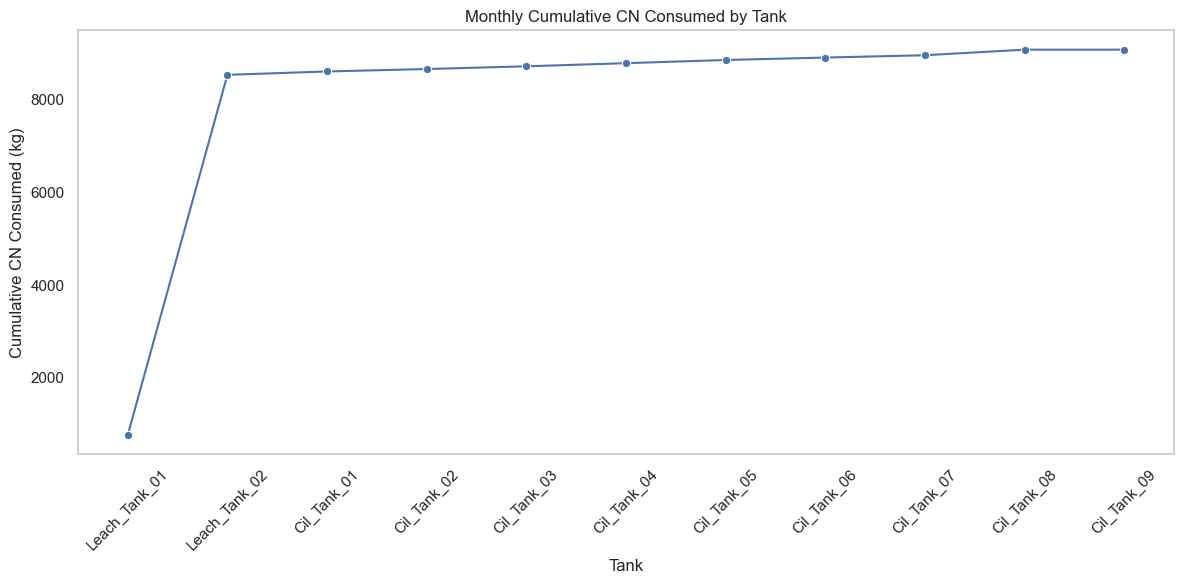

In [837]:
month = "2025-03"
monthly_summary = summary_df[summary_df["Month"] == month]
monthly_tanks = tank_df[tank_df["Month"] == month]

# Aggregate summary
monthly_totals = monthly_summary[["CN_Loss_kg", "Dry_Tonnes", "Daily_NaCN_Added_kg"]].sum()
monthly_totals["Net_CN_Consumed_kg"] = monthly_totals["Daily_NaCN_Added_kg"] - monthly_totals["CN_Loss_kg"]
monthly_totals["CN_Consumption_kg_per_tonne"] = monthly_totals["Net_CN_Consumed_kg"] / monthly_totals["Dry_Tonnes"]

# Print the summary
print(f"📅 Monthly Summary for {month}")
print(f"  Dry tonnes processed:         {monthly_totals['Dry_Tonnes']:.2f} t")
print(f"  NaCN added:                   {monthly_totals['Daily_NaCN_Added_kg']:.2f} kg")
print(f"  CN loss to tailings:          {monthly_totals['CN_Loss_kg']:.2f} kg")
print(f"  Net CN consumed:              {monthly_totals['Net_CN_Consumed_kg']:.2f} kg")
print(f"  CN consumption per tonne:     {monthly_totals['CN_Consumption_kg_per_tonne']:.3f} kg/t")


# Sum over tanks across all days in the month
monthly_tank_totals = (
    monthly_tanks.groupby("Tank")
    .agg({
        "CN_ppm": "mean",
        "CN_Mass_kg": "mean",
        "CN_Consumed_kg": "sum",
        "Residence_Time_hr": "mean"
    })
    .reset_index()
    .sort_values("Tank")
)

# Add a field calculating CN consumption per tonne for each tank
monthly_tank_totals["CN_Consumption_kg_per_tonne"] = (
    monthly_tank_totals["CN_Consumed_kg"] / monthly_totals["Dry_Tonnes"]
)

# Reorder rows so that pre-leach tanks come first
preleach_fields = ["Leach_Tank_01", "Leach_Tank_02"]
cil_fields = [f"Cil_Tank_{i:02}" for i in range(1, 10)]
monthly_tank_totals = (
    monthly_tank_totals.set_index("Tank")
    .reindex(preleach_fields + cil_fields)
    .reset_index()
)

display(monthly_tank_totals)


# Define desired tank order explicitly
tank_order = [
    "Leach_Tank_01", "Leach_Tank_02",
    "Cil_Tank_01", "Cil_Tank_02", "Cil_Tank_03",
    "Cil_Tank_04", "Cil_Tank_05", "Cil_Tank_06",
    "Cil_Tank_07", "Cil_Tank_08", "Cil_Tank_09"
]

# Apply categorical ordering
monthly_tank_totals["Tank"] = pd.Categorical(
    monthly_tank_totals["Tank"],
    categories=tank_order,
    ordered=True
)

# Sort by the defined order
monthly_tank_totals = monthly_tank_totals.sort_values("Tank")

# Compute cumulative consumption
monthly_tank_totals["Cumulative_CN_Consumed"] = monthly_tank_totals["CN_Consumed_kg"].cumsum()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_tank_totals, x="Tank", y="Cumulative_CN_Consumed", marker='o')
plt.title("Monthly Cumulative CN Consumed by Tank")
plt.xlabel("Tank")
plt.ylabel("Cumulative CN Consumed (kg)")
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

### 📈 6.3 Multi-Month Cumulative CN Visualisation
Builds a tank-level monthly summary across all months. Calculates cumulative CN consumed per tank per month, visualises trends across the circuit, and tracks proportional contribution by tank.

In [838]:
# --- Build monthly_tank_totals for all months ---
# Group across all months
all_monthly_tank_totals = (
    tank_df.groupby(["Month", "Tank"], observed=True)
    .agg({
        "CN_ppm": "mean",
        "CN_Mass_kg": "mean",
        "CN_Consumed_kg": "sum",
        "Residence_Time_hr": "mean"
    })
    .reset_index()
)

# --- Reorder Tank & Compute Cumulative per Month ---
# Define tank order
tank_order = ["Leach_Tank_01", "Leach_Tank_02"] + [f"Cil_Tank_{i:02}" for i in range(1, 10)]

# Ensure Tank column is a category with defined order
all_monthly_tank_totals["Tank"] = pd.Categorical(
    all_monthly_tank_totals["Tank"],
    categories=tank_order,
    ordered=True
)

# Sort properly
all_monthly_tank_totals = all_monthly_tank_totals.sort_values(["Month", "Tank"])

# Compute cumulative per month
all_monthly_tank_totals["Cumulative_CN_Consumed"] = (
    all_monthly_tank_totals.groupby("Month", observed=True)["CN_Consumed_kg"].cumsum()
)

# Convert Month to datetime and format as 'YY-MMM'
all_monthly_tank_totals["Month_Formatted"] = (
    all_monthly_tank_totals["Month"].dt.to_timestamp().dt.strftime("%y-%b")
)

# Ensure Month is datetime for label formatting
all_monthly_tank_totals["Month_dt"] = all_monthly_tank_totals["Month"].dt.to_timestamp()

# Calculate proportion and cumulative %
all_monthly_tank_totals["Proportion"] = all_monthly_tank_totals.groupby("Month")["CN_Consumed_kg"].transform(lambda x: x / x.sum())
all_monthly_tank_totals["Cumulative_Pct"] = all_monthly_tank_totals.groupby("Month")["CN_Consumed_kg"].cumsum()
all_monthly_tank_totals["Cumulative_Pct"] = all_monthly_tank_totals["Cumulative_Pct"] / all_monthly_tank_totals.groupby("Month")["CN_Consumed_kg"].transform("sum")

# Format hover text
all_monthly_tank_totals["HoverText"] = (
    "Period: " + all_monthly_tank_totals["Month_dt"].dt.strftime("%b %Y") + "<br>" +
    "CN Consumed: " + all_monthly_tank_totals["CN_Consumed_kg"].round(0).astype(int).astype(str) + " kg<br>" +
    "Proportion: " + (100 * all_monthly_tank_totals["Proportion"]).round(1).astype(str) + " %<br>" +
    "Cum.: " + (100 * all_monthly_tank_totals["Cumulative_Pct"]).round(1).astype(str) + " %"
)

# --- Plot Monthly Cumulative CN Consumed by Tank ---
fig = px.line(
    all_monthly_tank_totals,
    x="Tank",
    y="Cumulative_CN_Consumed",
    color=all_monthly_tank_totals["Month_dt"].dt.strftime("%y-%b"),
    custom_data=["HoverText"],
    markers=True,
)

# Show hover template
fig.update_traces(
    hovertemplate="%{customdata[0]}"
)

fig.update_layout(
    title="Monthly Cumulative CN Consumed by Tank",
    xaxis=dict(
        title="Tank",
        showgrid=False,
    ),
    yaxis=dict(
        title="Cumulative CN Consumed (kg)",
        showgrid=False,
        zeroline=True,
        zerolinecolor='LightGray',
        gridcolor='LightGray'
    ),
    legend_title="Month",
    height=600,
    width=800
)

fig.show()

### ⚱️ 6.4 Gold Dissolution Profiling
Extracts and melts dissolved gold profiles across tanks, normalises to grams dissolved per month, and plots monthly tank-wise gold dissolution for diagnostic comparison.

In [839]:
# Define pre-leach and CIL tank names and order
preleach_tanks = ["Leach_Tank_01", "Leach_Tank_02"]
cil_tanks = [f"Cil_Tank_{i:02}" for i in range(1, 10)]
all_tanks = preleach_tanks + cil_tanks

# Extract the Gold Dissolution Columns
gold_cols = [col for col in df.columns if col.startswith("Dissolved_Gold_Metal_Profile_G_Milled_Tons_")]

# Map to tank names
col_to_tank = {
    col: col.replace("Dissolved_Gold_Metal_Profile_G_Milled_Tons_", "") 
    for col in gold_cols
}

# Melt to Long Format for Easy Plotting
gold_df = df[["Date", "Leach_Solids"] + gold_cols].copy()
gold_df = gold_df.melt(id_vars=["Date", "Leach_Solids"], value_vars=gold_cols, var_name="Tank_Col", value_name="Dissolved_GPT")

# Extract tank name
gold_df["Tank"] = gold_df["Tank_Col"].str.replace("Dissolved_Gold_Metal_Profile_G_Milled_Tons_", "")

# Calculate grams dissolved = g/t × tonnes
gold_df["Dissolved_Au_grams"] = gold_df["Dissolved_GPT"] * gold_df["Leach_Solids"]

# Filter to only tanks of interest (if needed)
gold_df = gold_df[gold_df["Tank"].isin(all_tanks)]


# Add month and aggregate
gold_df["Date"] = pd.to_datetime(gold_df["Date"])
gold_df["Month"] = gold_df["Date"].dt.to_period("M")

# Sum grams per tank per month
monthly_dissolved_au = (
    gold_df.groupby(["Month", "Tank"], observed=True)["Dissolved_Au_grams"].sum().reset_index()
)

# Apply Tank order and sort
monthly_dissolved_au["Tank"] = pd.Categorical(
    monthly_dissolved_au["Tank"],
    categories=all_tanks,
    ordered=True
)

monthly_dissolved_au = monthly_dissolved_au.sort_values(["Month", "Tank"])


# Plot Dissolved Gold by Tank
fig = px.line(
    monthly_dissolved_au,
    x="Tank",
    y="Dissolved_Au_grams",
    color=monthly_dissolved_au["Month"].dt.strftime("%y-%b"),
    markers=True
)

fig.update_layout(
    title="Monthly Dissolved Gold by Tank",
    xaxis_title="Tank",
    yaxis_title="Dissolved Gold (g/month)",
    legend_title="Month",
    height=600,
    width=800,
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=False)
)

fig.show()



### ⚖️ 6.5 Gold-Based CN Reweighting Comparison
Compares original tank-wise CN consumption to gold-weighted consumption. Reassigns CN usage based on proportion of Au dissolved. Plots cumulative CN consumption and difference from original estimate. Adds adjusted total CN used to the main dataset.

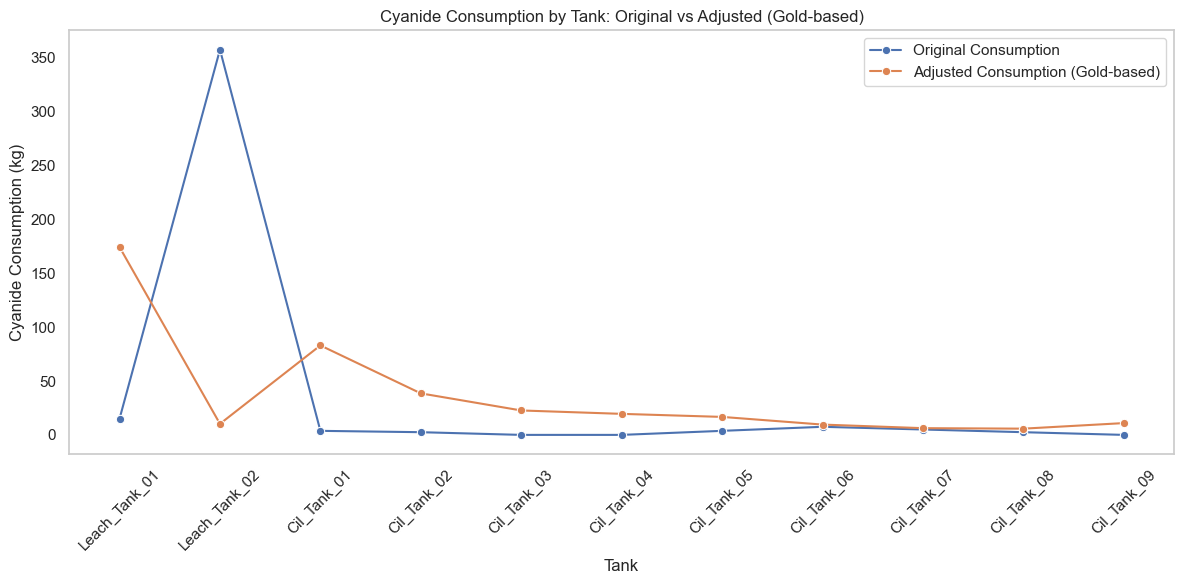

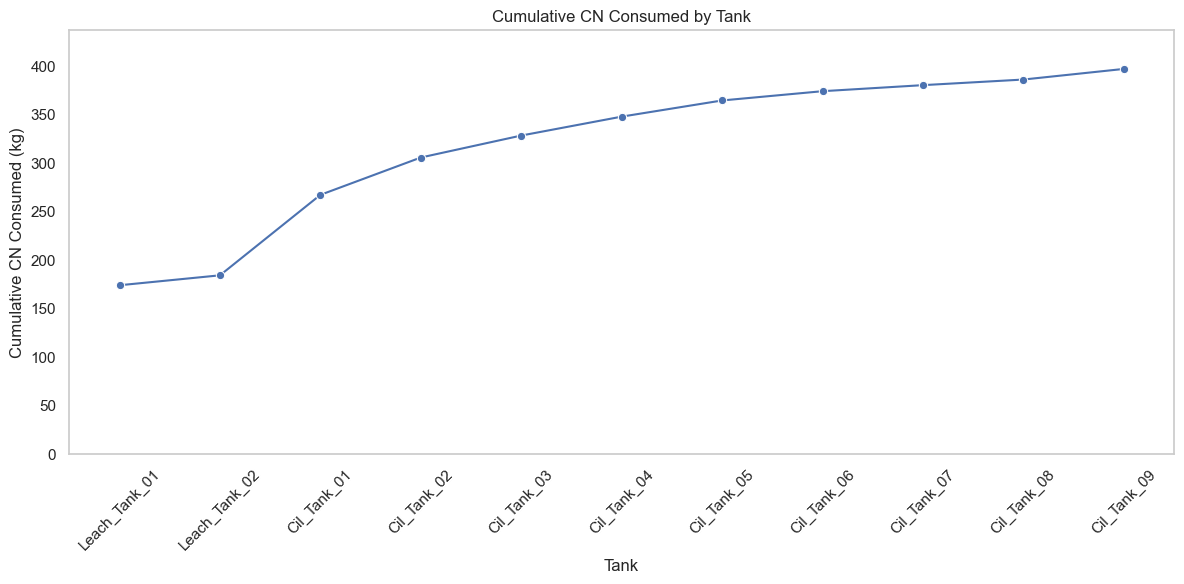

In [840]:
# With gold-based reweighting:
row = df.iloc[0]
tanks, cn_loss, dry_tonnes, density, estimated_added_kg = estimate_daily_cyanide_consumption(row, use_gold_weighting=True)

# Without gold-based weighting (original behaviour):
tanks_adjusted, *_ = estimate_daily_cyanide_consumption(row, use_gold_weighting=True)

# Plot CN_Consumed Adjusted vs Original in a line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=tanks, x="Tank", y="CN_Consumed_kg", marker='o', label='Original Consumption')
sns.lineplot(data=tanks_adjusted, x="Tank", y="CN_Consumed_Adjusted_kg", marker='o',
             label='Adjusted Consumption (Gold-based)')
plt.title("Cyanide Consumption by Tank: Original vs Adjusted (Gold-based)")
plt.xlabel("Tank")
plt.ylabel("Cyanide Consumption (kg)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Apply categorical ordering
tanks_adjusted["Tank"] = pd.Categorical(
    tanks_adjusted["Tank"],
    categories=tank_order,
    ordered=True
)

# Sort by the defined order
tanks_adjusted = tanks_adjusted.sort_values("Tank")

# Compute cumulative consumption
tanks_adjusted["Cum_CN_Consumed"] = tanks_adjusted["CN_Consumed_Adjusted_kg"].cumsum()


# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=tanks_adjusted, x="Tank", y="Cum_CN_Consumed", marker='o')
plt.title("Cumulative CN Consumed by Tank")
plt.xlabel("Tank")
plt.ylabel("Cumulative CN Consumed (kg)")
plt.xticks(rotation=45)
plt.ylim(0, tanks_adjusted["Cum_CN_Consumed"].max() * 1.1)
plt.grid(False)
plt.tight_layout()
plt.show()


def calc_cn_used_column(df, use_gold_weighting=True):
    """
    Updates the DataFrame to include a column with cyanide usage calculated via tank-level estimates.
    """
    cn_used_kg = []

    for idx, row in df.iterrows():
        df_tanks, *_ = estimate_daily_cyanide_consumption(row, use_gold_weighting=use_gold_weighting)
        total_cn = df_tanks["CN_Consumed_Adjusted_kg"].sum()
        cn_used_kg.append(total_cn)

    df["CN_Used_Kg"] = cn_used_kg
    return df

# Update the DataFrame with the new CN Used column
df = calc_cn_used_column(df, use_gold_weighting=True)

### Step 6.6 Building a Forecasting UI

In [841]:
# Define the forecast function
def forecast_cn_consumption(forecast_df: pd.DataFrame,
                            cn_price_per_kg: float = 3.5,
                            use_gold_weighting: bool = True):
    """
    Simulate CN consumption for a forecast of daily production inputs.
    """
    forecast_results = []

    for _, row in forecast_df.iterrows():
        simulated_row = base_template_row.copy()
        simulated_row.update(row.to_dict())

        # Estimate CN consumption using existing function
        df_tanks, cn_loss, dry_tonnes, slurry_density, estimated_added_kg = estimate_daily_cyanide_consumption(
            pd.Series(simulated_row), use_gold_weighting=use_gold_weighting
        )

        total_cn = df_tanks["CN_Consumed_Adjusted_kg"].sum()
        cost_usd = total_cn * cn_price_per_kg

        forecast_results.append({
            "Date": row["Date"],
            "Dry_Tonnes": dry_tonnes,
            "CN_Used_Kg": total_cn,
            "Tailings_CN_Loss_Kg": cn_loss,
            "Estimated_CN_Cost_USD": cost_usd,
            "Actual CN ppm": row.get("CN_Concentration_PL_01", np.nan),
        })

    return pd.DataFrame(forecast_results)


# Define a representative base template row using median values from dataset
base_template_row = df.median(numeric_only=True).to_dict()

# Add required string columns
base_template_row.update({"Date": "2025-01-01"})

# Prepare a test forecast using actual historical data for 7 days
test_forecast_input = df[[
    "Date",
    "Au_Grade",
    "Leach_Feed_Throughput_M3Day",
    "Percentsolids",
    "CN_Concentration_PL_01",
    "Dissolved_Oxygen_PL_01",
    "Particle_Size"
]].rename(columns={
    "CN_Concentration_PL_01": "Forecast_CN_ppm",
    "Dissolved_Oxygen_PL_01": "Forecast_DO_ppm",
    "Particle_Size": "Particle_Size_UF"  # placeholder, assuming all ultra-fine for test
}).head(7)

# Fill missing groupings
test_forecast_input["Particle_Size_F"] = 0
test_forecast_input["Particle_Size_C"] = 0

# Run forecast
forecast_results = forecast_cn_consumption(test_forecast_input)

forecast_results
base_template_row

{'Leach_Feed_Throughput_M3Hr': 143.53296940222816,
 'Leach_Feed_Throughput_M3Day': 3401.9696829880913,
 'Percentsolids': 50.0,
 'Leach_Feed_Grade_Au_Gt_Ds': 2.1550000000000002,
 'Leach_Feed_Grade_Au_Gt_Ns': 2.14,
 'Au_Grade': 2.152727995110024,
 'Leach_Feed_Grade_Ag_Gt_Ds': 5.16,
 'Leach_Feed_Grade_Ag_Gt_Ns': 4.985,
 'Leach_Feed_Grade_Ag_Gt_Day': 5.13,
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1': 390.0,
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2': 400.0,
 'Daily_Nacn_Consumption_Kgt': 0.0,
 'Mtd_Nacn_Consumption_Kgt': 0.5516944327105142,
 'Nacn_Used_T': 0.0,
 'Au_Feed_Grams': 5182.88708110709,
 'CN_Tailings_Concentration': 280.0,
 'Au_Tailings_Grams': 629.9310667094512,
 'Leach_Feed_Gt_150um_Day': 8.944478144036072,
 'Leach_Feed_Gt_75um_Day': 17.63861474969995,
 'Leach_Feed_Lt_75um_Day': 73.94220964892912,
 'Cyanide_Profile_Ppm_Leach_Tank_1': 380.0,
 'Cyanide_Profile_Ppm_Leach_Tank_2': 397.5,
 'Cyanide_Profile_Ppm_Cil_Tank_01': 385.0,
 'Cyanide_Profile_Ppm_Cil_Tank_02': 380.0,
 'Cyanide_Profile_Ppm_

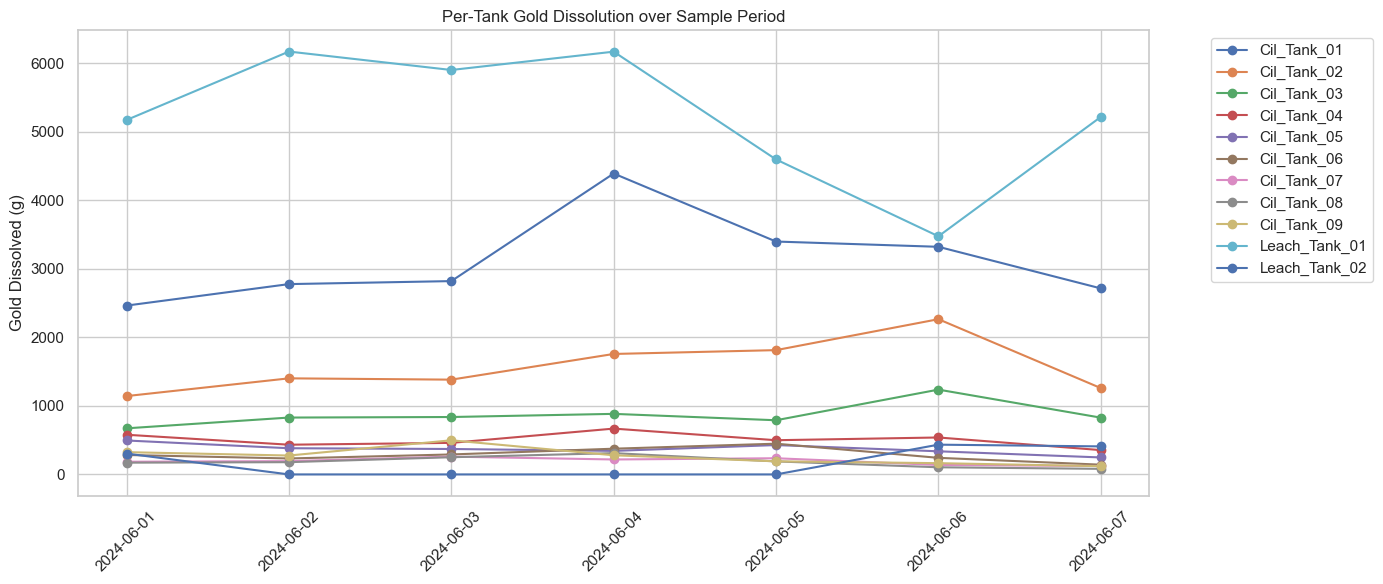

In [842]:
# Select a 7-day sample where data is complete and within a reasonable date range
sample_df = summary_df.dropna(subset=["Reported_Au_Feed_Grams", "Total_Gold_Dissolved_g"]).copy()
sample_df = sample_df.head(7).copy()  # first 7 days

# Extract tank-level gold recovery contributions
tank_cols = [col for col in sample_df.columns if col.startswith("Dissolved_Gold_")]
tank_recovery_df = sample_df[["Date"] + tank_cols].copy()

# Melt into long format for plotting
tank_recovery_long = tank_recovery_df.melt(id_vars="Date", var_name="Tank", value_name="Gold_Dissolved_g")
tank_recovery_long["Tank"] = tank_recovery_long["Tank"].str.replace("Dissolved_Gold_", "").str.replace("_g", "")

# Plot per-tank contribution
plt.figure(figsize=(14, 6))
for tank, tank_data in tank_recovery_long.groupby("Tank"):
    plt.plot(tank_data["Date"], tank_data["Gold_Dissolved_g"], marker="o", label=tank)

plt.xticks(rotation=45)
plt.ylabel("Gold Dissolved (g)")
plt.title("Per-Tank Gold Dissolution over Sample Period")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 🤖 Step 7: Train and evaluate XGBoost model

Fit a tree-based model to predict recovery from selected features and compare against kinetic estimates.

In [843]:
# Define features and target for modeling
features = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
]

# Ensure all features are numeric and handle NaNs
df_model = df[features + [target]].dropna()

X = df_model[features]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_sample_size,
                                                    random_state=random_seed)

# Train model
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
model.fit(X, y)

# Predict and evaluate
pred = model.predict(X_test)
mae = mean_absolute_error(y_test, pred)
r2 = model.score(X_test, y_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# Print evaluation metrics
print(f'Mean Absolute Error: {mae:.2f}')
print(f'R^2 Score: {r2:.4f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 0.41
R^2 Score: 0.9724
Root Mean Squared Error: 0.51


In [844]:
i = 10

# Use model to predict recovery on a test row
test_row = X_test.iloc[i]
predicted_recovery = model.predict(test_row.values.reshape(1, -1))[0]
print(f"Predicted Recovery for test row {i}: {predicted_recovery:.2f}%")
print(f"Actual Recovery for test row {i}: {y_test.iloc[i]:.2f}%")

Predicted Recovery for test row 10: 88.84%
Actual Recovery for test row 10: 88.24%


### 🔍 Step 6.1: Evaluate predictions and residuals

Use the trained model to predict recovery, analyse residuals, and visualise model fit.

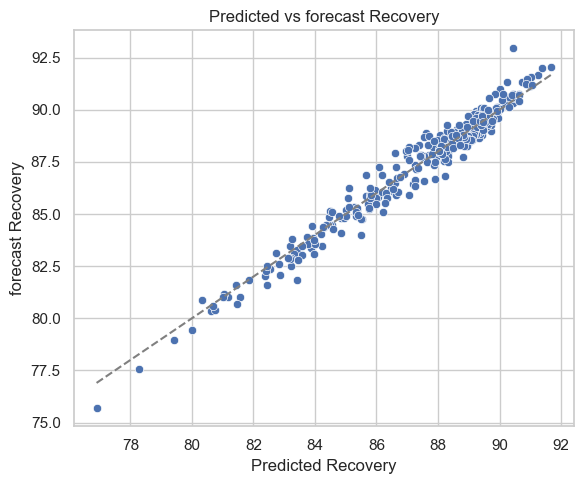

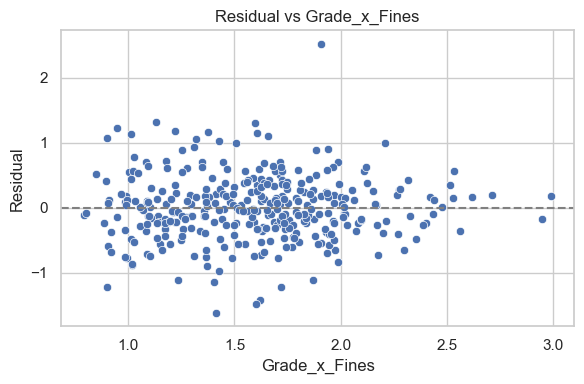

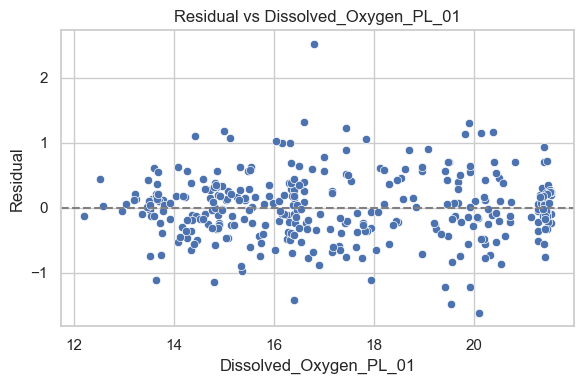

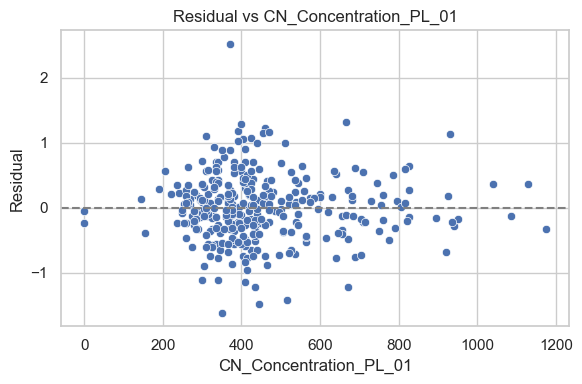

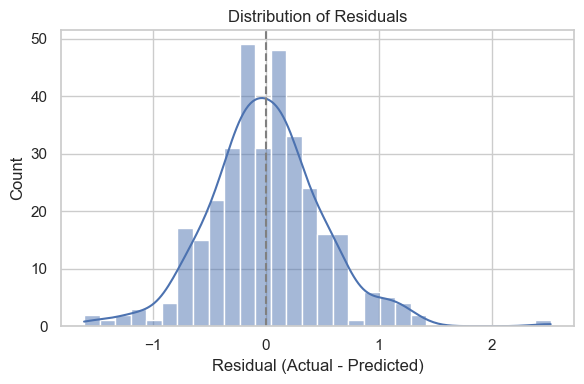

In [845]:
# Model predictions on the full dataset

# --- Predict using trained model ---
df_model["Predicted_Recovery"] = model.predict(X)
df_model["Residual"] = df_model[target] - df_model["Predicted_Recovery"]


# --- Plot Actual vs Predicted Recovery ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x="Predicted_Recovery", y=target, data=df_model)
plt.plot([df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
         [df_model["Predicted_Recovery"].min(), df_model["Predicted_Recovery"].max()],
         linestyle='--', color='grey')
plt.xlabel("Predicted Recovery")
plt.ylabel("forecast Recovery")
plt.title("Predicted vs forecast Recovery")
plt.tight_layout()
plt.show()


# --- Plot Residuals vs Key Features ---
for col in ["Grade_x_Fines",
            "Dissolved_Oxygen_PL_01",
            "CN_Concentration_PL_01"]:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=col, y="Residual", data=df_model)
    plt.axhline(0, color='grey', linestyle='--')
    plt.title(f"Residual vs {col}")
    plt.tight_layout()
    plt.show()


# --- Plot Histogram of residuals ---
plt.figure(figsize=(6, 4))
sns.histplot(df_model["Residual"], kde=True, bins=30)
plt.axvline(0, color='grey', linestyle='--')
plt.title("Distribution of Residuals")
plt.xlabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.show()


# --- Add predicted recovery back to the original dataframe ---
df["Predicted_Recovery"] = df_model["Predicted_Recovery"]

### 🧠 Step 6.2: Interpret model with SHAP

Assess feature importance using SHAP values and traditional model importances.

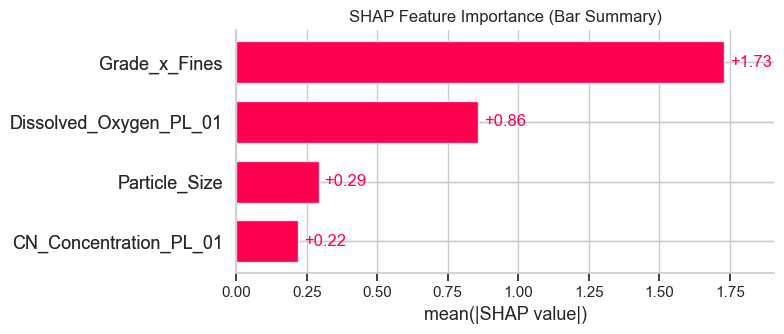

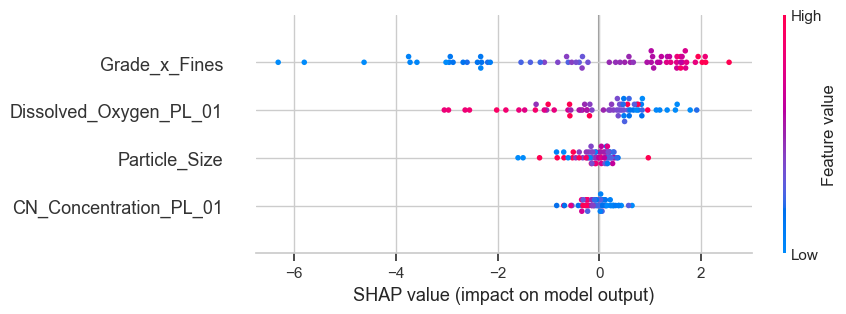

Grade_x_Fines             0.638
Dissolved_Oxygen_PL_01    0.208
CN_Concentration_PL_01    0.077
Particle_Size             0.077
dtype: float32

In [846]:
# Create importance Series
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

# Create SHAP explainer and compute SHAP values
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Plot summary of SHAP values (bar + beeswarm)
plt.figure(figsize=(10, 5))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("SHAP Feature Importance (Bar Summary)")
plt.tight_layout()
plt.show()

# Plot Beeswarm summary for detailed distribution
shap.plots.beeswarm(shap_values, max_display=15)

# Display feature importance to 2 decimal places
feature_importance = feature_importance.round(3)
feature_importance

## ⚖️ Step 7: Compare model performance

Assess accuracy and predictive alignment of the kinetic and ML models, and decide on the preferred approach for further use.

XGB -> R²: 0.9691, RMSE: 0.50, MAE: 0.38
Kinetic Model -> R²: 0.3323, RMSE: 10.15, MAE: 9.83


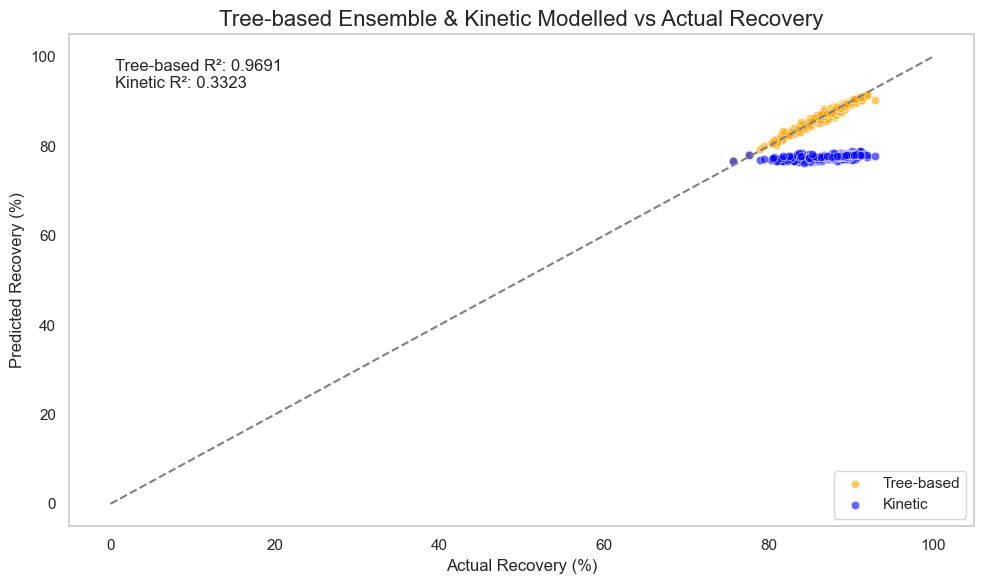

In [847]:
def evaluate_model(true, pred, label):
    # Calculate R²
    r2 = np.corrcoef(true, pred)[0, 1] ** 2
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae = mean_absolute_error(true, pred)
    print(f"{label} -> R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")

evaluate_model(df["Actual_Recovery"], df["Predicted_Recovery"], "XGB")
evaluate_model(df["Actual_Recovery"], df["Kinetic_Recovery"], "Kinetic Model")

# Plot predicted vs actual recovery for both models
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Actual_Recovery", y="Predicted_Recovery", data=df,
                label="Tree-based", color="orange", alpha=0.6)
sns.scatterplot(x="Actual_Recovery", y="Kinetic_Recovery", data=df,
                label="Kinetic", color="blue", alpha=0.6)
plt.plot([0, 100], [0, 100], linestyle="--", color="gray")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Recovery (%)")
plt.title("Tree-based Ensemble & Kinetic Modelled vs Actual Recovery", fontsize=16)
plt.legend()
plt.grid(False)
# Add performance metrics to the plot
plt.text(0.05, 0.95, f"Tree-based R²: {np.corrcoef(df['Actual_Recovery'],
            df['Predicted_Recovery'])[0, 1]**2:.4f}\n"
            f"Kinetic R²: {np.corrcoef(df['Actual_Recovery'], df['Kinetic_Recovery'])[0, 1]**2:.4f}",
            transform=plt.gca().transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()

## 💰 Step 8: Calculate economic performance

Estimate gold revenue, reagent costs, and net value per row using actual plant data.

In [848]:
# --- Gold Revenue Calculation ---
df['Actual_Gold_Revenue'] = (
    df['Tonnes_Processed'] * df['Au_Grade'] * df['Actual_Recovery'] / 100 * GOLD_PRICE_USD_PER_G
)

gold_produced = (df['Au_Feed_Grams'] - df['Au_Tailings_Grams'])
df['Alt_Gold_Revenue'] =  gold_produced * GOLD_PRICE_USD_PER_G

# --- Cyanide and Dissolved Oxygen Costs ---
df['Actual_CN_Cost'] = df['NaCN_Used_Kg'] * NACN_PRICE_USD_PER_KG
df['Actual_DO_Cost'] = df['Dissolved_Oxygen_PL_01'] * df['Solution_Mass_Kg'] / 1e6 * DO_PRICE_USD_PER_KG

# --- Actual Net Value Calculation ---
df['Actual_Net_Value_USD'] = (
    df['Actual_Gold_Revenue'] - df['Actual_CN_Cost'] - df['Actual_DO_Cost']
)

# Display the first 10 rows of the final DataFrame with rounded values
df[['Actual_Gold_Revenue', 'Actual_CN_Cost', 'Actual_DO_Cost', 
    'Actual_Net_Value_USD']].round(2).head(10)

,Actual_Gold_Revenue,Actual_CN_Cost,Actual_DO_Cost,Actual_Net_Value_USD
0,747230.66,3139.40,1.53,744089.73
1,884168.59,3070.48,1.54,881096.56
2,914504.11,2858.04,1.55,911644.51
3,818130.12,3279.57,1.55,814849.01
4,619906.06,2504.95,1.56,617399.56
5,695183.13,2469.70,1.56,692711.87
6,787979.47,2778.24,1.57,785199.66
7,742026.53,1907.77,1.48,740117.28
8,599506.42,2687.58,1.56,596817.29
9,581012.03,2410.56,1.55,578599.93


## 📉 Step 9: Visualise CN and DO distributions

Examine the distribution of cyanide and dissolved oxygen concentrations, and their relationship to recovery. Overlay configured operating bounds for interpretability.

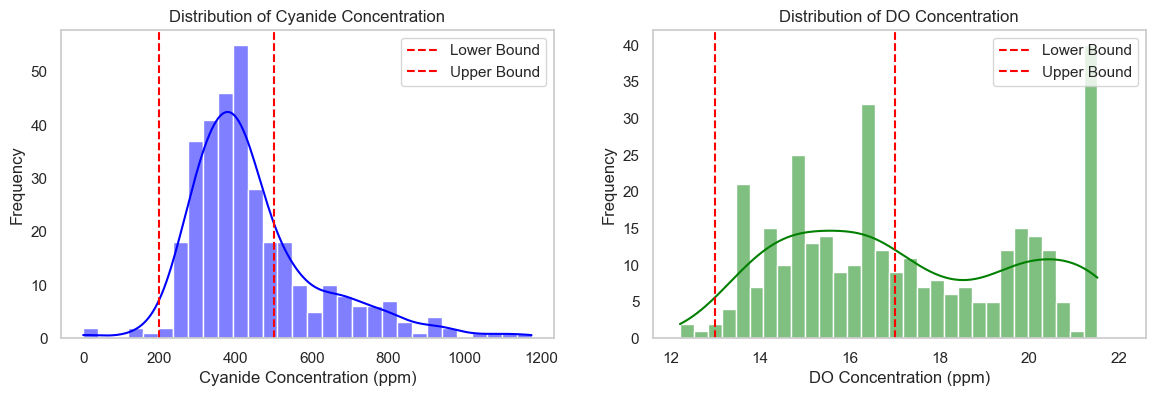

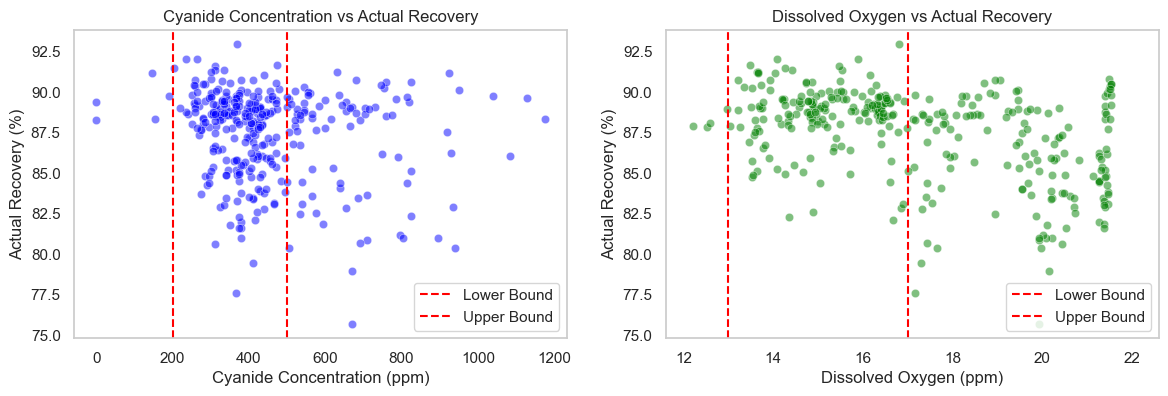

In [849]:
# Plot subplot distributions of CN Concentration and DO Concentration
plt.figure(figsize=(14, 4))

# Plot distribution of CN Concentration
plt.subplot(1, 2, 1)
sns.histplot(df['CN_Concentration_PL_01'], bins=30, kde=True, color='blue')
plt.title("Distribution of Cyanide Concentration")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Frequency")
plt.axvline(cn_lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(cn_upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.grid(False)
plt.legend()

# Plot distribution of DO Concentration
plt.subplot(1, 2, 2)
sns.histplot(df['Dissolved_Oxygen_PL_01'], bins=30, kde=True, color='green')
plt.title("Distribution of DO Concentration")
plt.xlabel("DO Concentration (ppm)")
# Set min/max axis limits
plt.xlim(df['Dissolved_Oxygen_PL_01'].min() * 0.95, df['Dissolved_Oxygen_PL_01'].max() * 1.05)
plt.ylabel("Frequency")
plt.axvline(do_lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(do_upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.legend()
plt.grid(False)
plt.show()

# Plot distribution of CN Concentration with Recoveries
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
sns.scatterplot(x='CN_Concentration_PL_01', y='Actual_Recovery', data=df, alpha=0.5, color='blue')
plt.axvline(cn_lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(cn_upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.title("Cyanide Concentration vs Actual Recovery")
plt.xlabel("Cyanide Concentration (ppm)")
plt.ylabel("Actual Recovery (%)")
plt.grid(False)
plt.legend()

plt.subplot(1, 2, 2)
sns.scatterplot(x='Dissolved_Oxygen_PL_01', y='Actual_Recovery', data=df, alpha=0.5, color='green')
plt.axvline(do_lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(do_upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.title("Dissolved Oxygen vs Actual Recovery")
plt.xlabel("Dissolved Oxygen (ppm)")
plt.xlim(df['Dissolved_Oxygen_PL_01'].min() * 0.95, df['Dissolved_Oxygen_PL_01'].max() * 1.05)
plt.ylabel("Actual Recovery (%)")
plt.legend(loc='lower right')
plt.grid(False)
plt.show()

## ✅ Step 10: Simulate model response and extract operational bands

### 🧮 Step 10.1: Simulate model response grid

Use the trained XGBoost model to predict recovery across a range of CN and DO values, capturing the response surface for each row.

In [850]:
def simulate_band_grid(row, model, cn_range, do_range,
                       grade_field="Au_Grade", recovery_field="Recovery",
                       solids_field="Percentsolids", tonnes_field="Tonnes_Processed"):

    grade_fines = row["Grade_x_Fines"]
    psd = row["Particle_Size"]
    solids_fraction = row[solids_field] / 100
    au_grade = row[grade_field]
    tonnes = row[tonnes_field]

    grid = []

    for cn in cn_range:
        for do in do_range:
            recovery = model.predict(pd.DataFrame([{
                "Grade_x_Fines": grade_fines,
                "Particle_Size": psd,
                "Dissolved_Oxygen_PL_01": do,
                "CN_Concentration_PL_01": cn,
            }]))[0]

            grid.append({
                "CN": cn,
                "DO": do,
                recovery_field: recovery,
                grade_field: au_grade,
                "Solids_Fraction": solids_fraction,
                "Tonnes_Processed": tonnes,
            })

    return pd.DataFrame(grid)


# Apply once and optionally cache
fresh_load = True					# Set to True to force fresh load, False to use cached data

if fresh_load:
    df["Band_Grid"] = df.apply(lambda row: simulate_band_grid(row, model, cn_range, do_range), axis=1)
    df["Band_Grid"].to_pickle("band_grid_cache.pkl")
    fresh_load = False
else:
    df["Band_Grid"] = pd.read_pickle("band_grid_cache.pkl")

### 💸 Step 10.2: Calculate incremental economic value

For each simulated recovery scenario, compute revenue, reagent cost, and penalty-adjusted net value relative to a base recovery. Identify scenarios with the highest net gain.

In [851]:
# Define a Net Value Function
def compute_incremental_value_grid(grid_df, gold_price_g, nacn_price, do_price, penalty_weight,
                                   penalty_threshold, solids_field="Solids_Fraction",
                                   grade_field="Au_Grade", recovery_field="Recovery",
                                   tonnes_field="Tonnes_Processed", cn_field="CN",
                                   do_field="DO"):
    grid = grid_df.copy()
    
    # Gold revenue at actual recovery
    gold_recovered_g = grid[recovery_field] * grid[grade_field] / 100
    grid["Revenue"] = gold_recovered_g * gold_price_g * grid[tonnes_field]

    # Mass flows
    grid["Slurry_Mass_Kg"] = grid[tonnes_field] * 1000 / grid[solids_field]
    grid["Solution_Mass_Kg"] = grid["Slurry_Mass_Kg"] * (1 - grid[solids_field])

    # Reagent usage
    grid["CN_Used_Kg"] = (grid[cn_field] * grid["Solution_Mass_Kg"]) / 1e6
    grid["CN_kg_t"] = grid["CN_Used_Kg"] / grid[tonnes_field]

    grid["DO_Used_Kg"] = (grid[do_field] * grid["Solution_Mass_Kg"]) / 1e6

    grid["CN_Cost"] = grid["CN_Used_Kg"] * nacn_price
    grid["DO_Cost"] = grid["DO_Used_Kg"] * do_price
    grid["Penalty"] = grid[cn_field].apply(lambda x: penalty_weight * max(0, x - penalty_threshold))

    # Total cost
    grid["Total_Cost"] = grid["CN_Cost"] + grid["DO_Cost"] + grid["Penalty"]

    # Identify the optimal recovery row
    optimal_row = grid.loc[grid["Revenue"].idxmax()]
    optimal_recovery = optimal_row[recovery_field]

    # Cap forecast at optimal if needed
    base_recovery = min(grid[recovery_field], optimal_recovery)

    # Recovery gain
    grid["Recovery_Gain"] = grid[recovery_field] - base_recovery
    grid["Recovery_Gain"] = grid["Recovery_Gain"].clip(lower=0)

    # Incremental revenue
    grid["Revenue_Gain"] = (
        (grid["Recovery_Gain"] / 100) * grid[grade_field] * 
        grid[tonnes_field] * gold_price_g
    )

    # Incremental value = gain – cost
    grid["Incremental_Value"] = grid["Revenue_Gain"] - grid["Total_Cost"]

    return grid

### 📌 Step 10.3: Extract optimal CN/DO band

Identify the optimal CN and DO conditions that maximise incremental value. Define a recommended band around this optimum.

In [852]:
def extract_optimal_band(grid_df, value_field="Incremental_Value"):
    best_row = grid_df.loc[grid_df[value_field].idxmax()]
    best_value = best_row[value_field]

    # Band where value is within 98% of best value (handles negative values correctly)
    if best_value <= 0:
        band = grid_df[grid_df[value_field] >= best_value]  # fallback: just keep the top row
    else:
        band = grid_df[grid_df[value_field] >= 0.98 * best_value]

    # Defensive fallback: if band is empty, use just the best row
    if band.empty:
        band = pd.DataFrame([best_row])

    return pd.Series({
        "Optimal_CN": best_row["CN"],
        "Optimal_DO": best_row["DO"],
        "Optimal_Recovery": best_row["Recovery"],
        "Incremental_Value": best_value,
        "CN_Recommended_Low": band["CN"].min(),
        "CN_Recommended_High": band["CN"].max(),
        "DO_Recommended_Low": band["DO"].min(),
        "DO_Recommended_High": band["DO"].max()
    })



# Compute Net Value Grid
df["Band_Grid_Incremental"] = df.apply(
    lambda row: compute_incremental_value_grid(
        row["Band_Grid"], GOLD_PRICE_USD_PER_G, NACN_PRICE_USD_PER_KG, DO_PRICE_USD_PER_KG,
        penalty_weight, penalty_threshold, recovery_field="Actual_Recovery"
    ),
    axis=1
)

# Apply to updated band grid:
df_band_results = df["Band_Grid_Incremental"].apply(extract_optimal_band)
df = pd.concat([df, df_band_results], axis=1)

KeyError: 'Actual_Recovery'

## Kinetic Model Tuning

In [ ]:
# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.figsize': (16, 6)})

# Define tank mappings
tanks = {
    "Leach_Tank_01": {
        "CN": "CN_Concentration_PL_01",
        "DO": "Dissolved_Oxygen_PL_01",
        "RT": "Residence_Time_Leach_Tank_01_hr",
        "Gold": "Dissolved_Gold_Leach_Tank_01_g",
        "NaCN": "NaCN_Used_Leach_Tank_01_kg",
    },
    "Leach_Tank_02": {
        "CN": "Leach_Cn_Adds_To_Tank_2",
        "DO": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02",
        "RT": "Residence_Time_Leach_Tank_02_hr",
        "Gold": "Dissolved_Gold_Leach_Tank_02_g",
        "NaCN": "NaCN_Used_Leach_Tank_02_kg",
    }
}

# Add CIL tanks
for i in range(1, 10):
    tanks[f"Cil_Tank_{i:02}"] = {
        "CN": f"Cyanide_Profile_Ppm_Cil_Tank_0{i}",
        "DO": f"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_0{i}",
        "RT": f"Residence_Time_Cil_Tank_0{i}_hr",
        "Gold": f"Dissolved_Gold_Cil_Tank_0{i}_g",
        "NaCN": f"NaCN_Used_Cil_Tank_0{i}_kg",
    }

# Prepare data for melting
plot_data = []
for tank_name, fields in tanks.items():
    for metric in ["CN", "DO", "RT", "Gold", "NaCN"]:
        plot_data.append(pd.DataFrame({
            "Date": df["Date"],
            "Tank": tank_name,
            "Metric": metric,
            "Value": df[fields[metric]]
        }))

df_plot = pd.concat(plot_data)

# Display multi-metric plots
g = sns.FacetGrid(df_plot, col="Metric", col_wrap=2, sharey=False, height=4.5)
g.map_dataframe(sns.lineplot, x="Date", y="Value", hue="Tank", legend="full")
g.add_legend()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Time Series per Tank: CN, DO, Residence Time, Gold Dissolved, NaCN Used")
plt.show()


In [ ]:
# Extract residence time columns for leach and CIL tanks
leach_tank_times = [
    "Residence_Time_Leach_Tank_01_hr",
    "Residence_Time_Leach_Tank_02_hr"
]
cil_tank_times = [
    f"Residence_Time_Cil_Tank_0{i}_hr" for i in range(1, 10)
]

# Sanity check: make sure all columns exist
residence_time_columns = leach_tank_times + cil_tank_times
residence_times_available = all(col in df.columns for col in residence_time_columns)

# Preview the first few rows of these residence times
df_residence_times = df[residence_time_columns].head()

residence_times_available, df_residence_times

In [ ]:
# Extract tank-level residence times, CN usage, and dissolved gold for weighted recovery tuning
residence_time_cols = [col for col in df.columns if col.startswith("Residence_Time")]
cn_used_cols = [col for col in df.columns if col.startswith("NaCN_Used_")]
gold_dissolved_cols = [col for col in df.columns if col.startswith("Dissolved_Gold_")]

# Compute total residence time per day
df["Total_Residence_Time"] = df[residence_time_cols].sum(axis=1)

# Compute weighted average CN concentration and DO across all tanks
# First calculate residence-time-weighted CN and DO per tank
weighted_cn_sum = 0
weighted_do_sum = 0
total_res_time = df["Total_Residence_Time"]

for col in cn_used_cols:
    tank_id = col.replace("NaCN_Used_", "").replace("_kg", "")
    res_col = f"Residence_Time_{tank_id}_hr"
    cn_conc_col = f"Cyanide_Profile_Ppm_{tank_id}"
    if cn_conc_col in df.columns and res_col in df.columns:
        weighted_cn_sum += df[cn_conc_col] * df[res_col]
        
for col in gold_dissolved_cols:
    tank_id = col.replace("Dissolved_Gold_", "").replace("_g", "")
    res_col = f"Residence_Time_{tank_id}_hr"
    do_conc_col = f"Dissolved_Oxygen_Profile_Ppm_{tank_id}"
    if do_conc_col in df.columns and res_col in df.columns:
        weighted_do_sum += df[do_conc_col] * df[res_col]

# Compute final weighted averages
df["Weighted_CN_PPM"] = weighted_cn_sum / total_res_time
df["Weighted_DO_PPM"] = weighted_do_sum / total_res_time

# Show a sample of the new weighted fields
df[["Weighted_CN_PPM", "Weighted_DO_PPM"]].head()


In [ ]:
# Drop rows with missing critical values
df_clean = df.dropna(subset=[
    'Weighted_CN_PPM',
    'Weighted_DO_PPM',
    'Au_Grade',
    'Particle_Size',
    'Actual_Recovery'
]).copy()

# Define the kinetic model
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
                          gold_locked_fraction, k_base, cn_exponent,
                          do_exponent, liberation_factor):
    cn_ppm = max(cn_ppm, 1)
    do_ppm = max(do_ppm, 0.1)
    particle_size_um = max(particle_size_um, 1)

    liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))
    k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
    recovery_pct = liberation * (1 - np.exp(-k_effective))
    return recovery_pct * 100

# Objective function for optimisation
def objective(params, df):
    gold_locked_fraction, k_base, cn_exp, do_exp, lib_factor = params
    preds = df.apply(lambda row: calc_recovery_kinetic(
        row['Weighted_CN_PPM'],
        row['Weighted_DO_PPM'],
        row['Au_Grade'],
        row['Particle_Size'],
        gold_locked_fraction, k_base, cn_exp, do_exp, lib_factor
    ), axis=1)
    return mean_absolute_error(df['Actual_Recovery'], preds)

# Initial guesses
initial_params = [0.1, 0.005, 0.8, 0.6, 1.8]

# Bounds for the parameters to ensure they remain within physical limits
bounds = [
    (0.01, 0.5),  # locked gold fraction
    (1e-5, 0.05), # k_base
    (0.1, 2.0),   # cn_exponent
    (0.1, 2.0),   # do_exponent
    (0.1, 5.0)    # liberation factor
]

# Perform optimisation
result = minimize(objective, initial_params, args=(df_clean,), bounds=bounds, method='L-BFGS-B')

# Extract best parameters
best_params = result.x

# Predict recovery using the tuned model
df_clean['Recovery_Kinetic_Tuned'] = df_clean.apply(lambda row: calc_recovery_kinetic(
    row['Weighted_CN_PPM'],
    row['Weighted_DO_PPM'],
    row['Au_Grade'],
    row['Particle_Size'],
    *best_params
), axis=1)

# Evaluate performance
r2 = r2_score(df_clean['Actual_Recovery'], df_clean['Recovery_Kinetic_Tuned'])
mae = mean_absolute_error(df_clean['Actual_Recovery'], df_clean['Recovery_Kinetic_Tuned'])

# Display results
print(f"Optimised Parameters: {best_params}")
print(f"R² Score: {r2:.4f}, Mean Absolute Error: {mae:.2f}")


In [ ]:
# Define tank lists for CIL tanks
cil_tanks = [f"{i:02}" for i in range(1, 10)]

# Build full column names
cn_cols = [f"Cyanide_Profile_Ppm_Cil_Tank_{i}" for i in cil_tanks]
do_cols = [f"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_{i}" for i in cil_tanks]
residence_cols = [f"Residence_Time_Cil_Tank_{i}_hr" for i in cil_tanks]

# Multiply CN and DO by residence time for weighted average
df["Weighted_CN_PPM"] = (
    df[cn_cols].multiply(df[residence_cols].values).sum(axis=1) / df[residence_cols].sum(axis=1)
)

df["Weighted_DO_PPM"] = (
    df[do_cols].multiply(df[residence_cols].values).sum(axis=1) / df[residence_cols].sum(axis=1)
)

# Show the weighted values for verification
df[["Weighted_CN_PPM", "Weighted_DO_PPM"]].describe()


In [ ]:
# Drop rows with missing essential values
df_clean = df.dropna(subset=[
    "Weighted_CN_PPM", "Weighted_DO_PPM", "Au_Grade", "Particle_Size", "Actual_Recovery"
]).copy()

# Define the kinetic model
def kinetic_model(params, cn, do, grade, psd):
    k_base, cn_exp, do_exp, gold_locked, liberation_factor = params
    liberation = 1 - gold_locked * np.exp(-liberation_factor * (75 / psd))
    k_effective = k_base * (cn ** cn_exp) * (do ** do_exp)
    recovery = liberation * (1 - np.exp(-k_effective))
    return recovery * 100

# Objective function to minimise MAE
def objective(params, cn, do, grade, psd, actual):
    pred = kinetic_model(params, cn, do, grade, psd)
    return mean_absolute_error(actual, pred)

# Extract variables
cn_vals = df_clean["Weighted_CN_PPM"].values
do_vals = df_clean["Weighted_DO_PPM"].values
grade_vals = df_clean["Au_Grade"].values
psd_vals = df_clean["Particle_Size"].values
actual_recovery = df_clean["Actual_Recovery"].values

# Initial parameter guess: [k_base, cn_exponent, do_exponent, gold_locked_fraction, liberation_factor]
initial_params = [0.005, 0.8, 0.6, 0.1, 1.8]
bounds = [(1e-6, 0.1), (0.1, 2), (0.1, 2), (0, 0.5), (0.5, 5)]

# Optimise
result = minimize(
    objective,
    initial_params,
    args=(cn_vals, do_vals, grade_vals, psd_vals, actual_recovery),
    bounds=bounds,
    method="L-BFGS-B"
)

# Apply tuned model
tuned_params = result.x
df_clean["Tuned_Kinetic_Recovery"] = kinetic_model(
    tuned_params,
    cn_vals, do_vals, grade_vals, psd_vals
)

# Calculate final metrics
mae = mean_absolute_error(df_clean["Actual_Recovery"], df_clean["Tuned_Kinetic_Recovery"])
r2 = r2_score(df_clean["Actual_Recovery"], df_clean["Tuned_Kinetic_Recovery"])

tuned_params, mae, r2

print(f"Tuned Parameters: {tuned_params}")
print(f"Mean Absolute Error: {mae:.2f} | R² Score: {r2:.4f}")


In [ ]:
# Define tank mappings
leach_tanks = ["Leach_Tank_01", "Leach_Tank_02"]
cil_tanks = [f"Cil_Tank_0{i}" for i in range(1, 10)]
all_tanks = leach_tanks + cil_tanks

# Build CN and DO field mappings
cn_fields = {
    "Leach_Tank_01": "CN_Concentration_PL_01",
    "Leach_Tank_02": "Cyanide_Profile_Ppm_Leach_Tank_2",
    **{tank: f"Cyanide_Profile_Ppm_{tank}" for tank in cil_tanks}
}

do_fields = {
    "Leach_Tank_01": "Dissolved_Oxygen_PL_01",
    "Leach_Tank_02": "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02",
    **{tank: f"Dissolved_Oxygen_Profile_Ppm_{tank}" for tank in cil_tanks}
}

residence_time_fields = {
    tank: f"Residence_Time_{tank}_hr" for tank in all_tanks
}

# Function to compute weighted average with NaN handling
def weighted_average(values, weights):
    mask = ~pd.isna(values) & ~pd.isna(weights)
    if mask.sum() == 0:
        return float("nan")
    return (values[mask] * weights[mask]).sum() / weights[mask].sum()

# Compute weighted CN and DO concentrations across tanks
weighted_cn = []
weighted_do = []

for i, row in df.iterrows():
    cn_vals = pd.Series({tank: row.get(cn_fields[tank], float('nan')) for tank in all_tanks})
    do_vals = pd.Series({tank: row.get(do_fields[tank], float('nan')) for tank in all_tanks})
    rt_vals = pd.Series({tank: row.get(residence_time_fields[tank], float('nan')) for tank in all_tanks})
    
    weighted_cn.append(weighted_average(cn_vals, rt_vals))
    weighted_do.append(weighted_average(do_vals, rt_vals))

# Append to DataFrame
df["Weighted_CN_ppm"] = weighted_cn
df["Weighted_DO_ppm"] = weighted_do

# Preview new columns
df[["Weighted_CN_ppm", "Weighted_DO_ppm"]].describe()


In [ ]:
# Drop rows with missing target or inputs
df_tune = df.dropna(subset=[
    "Actual_Recovery", "Weighted_CN_ppm", "Weighted_DO_ppm",
    "Au_Grade", "Particle_Size"
])

# Extract input arrays
X_cn = df_tune["Weighted_CN_ppm"].values
X_do = df_tune["Weighted_DO_ppm"].values
X_grade = df_tune["Au_Grade"].values
X_size = df_tune["Particle_Size"].values
y_actual = df_tune["Actual_Recovery"].values

# Redefine kinetic model and objective
def kinetic_model(params, cn_ppm, do_ppm, grade, size_um):
    k_base, cn_exp, do_exp, locked_frac = params
    liberation = 1 - locked_frac * np.exp(-1.8 * (75 / size_um))
    k_effective = k_base * (cn_ppm ** cn_exp) * (do_ppm ** do_exp)
    recovery = liberation * (1 - np.exp(-k_effective))
    return recovery * 100

def objective(params, cn_ppm, do_ppm, grade, size_um, y_true):
    y_pred = kinetic_model(params, cn_ppm, do_ppm, grade, size_um)
    return mean_absolute_error(y_true, y_pred)

# Initial guess and bounds
initial_params = [0.005, 0.8, 0.6, 0.1]
bounds = [(1e-5, 1), (0.1, 2), (0.1, 2), (0.01, 0.5)]

# Optimise
result = minimize(
    objective,
    initial_params,
    args=(X_cn, X_do, X_grade, X_size, y_actual),
    method="L-BFGS-B",
    bounds=bounds
)

# Evaluate best fit
best_params = result.x
y_pred = kinetic_model(best_params, X_cn, X_do, X_grade, X_size)

mae = mean_absolute_error(y_actual, y_pred)
r2 = r2_score(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))

# Display the best parameters and evaluation metrics
print(f"Optimised Parameters: {best_params}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")



In [ ]:
# Clean DO fields (impute with rolling mean)
do_cols = [col for col in df.columns if "Dissolved_Oxygen" in col]
df[do_cols] = df[do_cols].replace(0, np.nan)
df[do_cols] = df[do_cols].fillna(df[do_cols].rolling(window=30, min_periods=1).mean())

# Cyanide and DO profile fields
cn_fields = [
    "CN_Concentration_PL_01",  # Leach Tank 1
    "Cyanide_Profile_Ppm_Leach_Tank_2"
] + [f"Cyanide_Profile_Ppm_Cil_Tank_0{i}" for i in range(1, 10)]

do_fields = [
    "Dissolved_Oxygen_PL_01",  # Leach Tank 1
    "Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02"
] + [f"Dissolved_Oxygen_Profile_Ppm_Cil_Tank_0{i}" for i in range(1, 10)]

rt_fields = [
    "Residence_Time_Leach_Tank_01_hr",
    "Residence_Time_Leach_Tank_02_hr"
] + [f"Residence_Time_Cil_Tank_0{i}_hr" for i in range(1, 10)]

# Calculate weighted average CN and DO
def weighted_avg(row, value_fields, weight_fields):
    values = pd.to_numeric(row[value_fields], errors='coerce').values
    weights = pd.to_numeric(row[weight_fields], errors='coerce').values
    mask = ~np.isnan(values) & ~np.isnan(weights)
    if mask.any():
        return np.average(values[mask], weights=weights[mask])
    return np.nan

# Apply corrected weighted average
df["CN_Weighted"] = df.apply(weighted_avg, axis=1, value_fields=cn_fields, weight_fields=rt_fields)
df["DO_Weighted"] = df.apply(weighted_avg, axis=1, value_fields=do_fields, weight_fields=rt_fields)

# Define the kinetic model
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
                          gold_locked_fraction,
                          k_base, cn_exponent, do_exponent,
                          liberation_factor=1.8):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)

    liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))
    k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
    recovery_pct = liberation * (1 - np.exp(-k_effective))
    return recovery_pct * 100

# Loss function
def kinetic_loss(params, df, locked_frac=0.5, liberation_factor=1.8):
    k_base, cn_exp, do_exp = params
    pred = calc_recovery_kinetic(
        df["CN_Weighted"], df["DO_Weighted"], df["Au_Grade"], df["Particle_Size"],
        gold_locked_fraction=locked_frac,
        k_base=k_base, cn_exponent=cn_exp, do_exponent=do_exp,
        liberation_factor=liberation_factor
    )
    return mean_absolute_error(df["Actual_Recovery"], pred)

# Run tuning with locked_frac fixed at 0.5
result_fixed_locked = minimize(
    kinetic_loss,
    x0=[0.9, 0.1, 0.2],
    args=(df, 0.5),
    bounds=[(1e-4, 5), (0.01, 2), (0.01, 2)],
    method='L-BFGS-B'
)

# Calculate predictions with fixed locked gold fraction
df["Kinetic_Recovery_FixedLocked"] = calc_recovery_kinetic(
    df["CN_Weighted"], df["DO_Weighted"], df["Au_Grade"], df["Particle_Size"],
    gold_locked_fraction=0.5,
    k_base=result_fixed_locked.x[0],
    cn_exponent=result_fixed_locked.x[1],
    do_exponent=result_fixed_locked.x[2]
)

# Evaluate performance
mae = mean_absolute_error(df["Actual_Recovery"], df["Kinetic_Recovery_FixedLocked"])
r2 = r2_score(df["Actual_Recovery"], df["Kinetic_Recovery_FixedLocked"])
rmse = np.sqrt(mean_squared_error(df["Actual_Recovery"], df["Kinetic_Recovery_FixedLocked"]))

# Display the results
print(f"Optimised Parameters (Fixed Locked Gold): {result_fixed_locked.x}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


In [ ]:
# Reload cleaned dataset with imputed DO values and valid tank-level metrics
df_clean = df.copy()

# Define kinetic model function with variable locked gold fraction
def kinetic_model(row, params):
    k_base, cn_exp, do_exp, locked_frac = params
    cn = max(row["CN_Weighted"], 1)
    do = max(row["DO_Weighted"], 0.1)
    ps = max(row["Particle_Size"], 1)
    grade = row["Au_Grade"]

    liberation = 1 - locked_frac * np.exp(-1.8 * (75 / ps))
    k_eff = k_base * (cn ** cn_exp) * (do ** do_exp)
    recovery = liberation * (1 - np.exp(-k_eff))
    return recovery * 100

# Objective function to minimise (MAE)
def objective(params):
    predictions = df_clean.apply(lambda row: kinetic_model(row, params), axis=1)
    return mean_absolute_error(df_clean["Actual_Recovery"], predictions)

# Initial guess: [k_base, cn_exp, do_exp, locked_frac]
initial_guess = [0.01, 0.5, 0.5, 0.5]
bounds = [(1e-5, 5), (0.01, 2), (0.01, 2), (0.01, 1)]

# Run optimisation
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
opt_params = result.x

# Calculate final predictions and metrics
df_clean["Kinetic_Recovery_V2"] = df_clean.apply(lambda row: kinetic_model(row, opt_params), axis=1)
mae = mean_absolute_error(df_clean["Actual_Recovery"], df_clean["Kinetic_Recovery_V2"])
rmse = np.sqrt(mean_squared_error(df_clean["Actual_Recovery"], df_clean["Kinetic_Recovery_V2"]))
r2 = r2_score(df_clean["Actual_Recovery"], df_clean["Kinetic_Recovery_V2"])

# Display the optimised parameters and performance metrics
print(f"Optimised Parameters: {opt_params}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Root Mean Squared Error: {rmse:.2f}")


In [ ]:
# Save the dataframe to CSV
df_clean.to_csv("modelling_data.csv", index=False)

### Apply cost and net value function

In [ ]:
def simulate_recovery(cn, do, grade, base_recovery=84.0):
    """
    Simulated gold recovery function responding to CN and DO.
    - Slightly higher with CN and DO
    - Capped to avoid unrealistic values
    - Penalised if below thresholds
    """
    # Parameters
    cn_effect = np.log1p(max(cn - 200, 1)) * 0.5
    do_effect = np.log1p(max(do - 2, 1)) * 1.0
    grade_effect = np.log1p(grade + 1) * 1.0

    recovery = base_recovery + cn_effect + 0.5 * do_effect + 0.2 * grade_effect

    # Cap between 70 and 95%
    return np.clip(recovery, 70, 95)


In [ ]:
rec_ref = 10

tonnes_processed = df.iloc[rec_ref]['Leach_Solids']  # Use the pre-calculated tonnes processed

# Test input (1 tonne, controlled conditions)
# Define ranges
cn_range = np.arange(5, 600 + 1, 15)  # ppm
do_range = np.arange(5, 25 + 1, 2)      # ppm

test_grid = []

for cn in cn_range:
    for do in do_range:
        recovery = simulate_recovery(
            cn,
            do,
            df.iloc[rec_ref]['Au_Grade'],
            base_recovery=df.iloc[rec_ref]['Actual_Recovery']
        )
        
        test_grid.append({
            "CN": cn,
            "DO": do,
            "Recovery": recovery,
            "Au_Grade": df.iloc[rec_ref]['Au_Grade'],
            "Solids_Fraction": df.iloc[rec_ref]['Solids_Fraction'],
            "Tonnes_Processed": df.iloc[rec_ref]['Leach_Solids']
        })


test_input_df = pd.DataFrame(test_grid)

# Run the grid evaluation
grid_result = compute_incremental_value_grid(
    test_input_df,
    GOLD_PRICE_USD_PER_G,
    NACN_PRICE_USD_PER_KG,
    DO_PRICE_USD_PER_KG,
    penalty_weight,
    penalty_threshold,
    forecast_recovery=df.iloc[rec_ref]['Actual_Recovery']
)

# Extract optimal band
band_result = extract_optimal_band(grid_result).round(2)
band_result


In [ ]:
pivot = grid_result.pivot(index="DO", columns="CN", values="Incremental_Value")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, fmt=".0f", cmap="YlGnBu")
plt.title("Incremental Value vs CN and DO")
plt.xlabel("CN (ppm)")
plt.ylabel("DO (ppm)")
plt.show()


In [ ]:
# Simulate CN/DO ranges with other required inputs
test_grid = []
for cn in cn_range:
    for do in do_range:
        test_grid.append({
            "Grade_x_Fines": df.iloc[rec_ref]['Grade_x_Fines'],
            "Particle_Size": df.iloc[rec_ref]['Particle_Size'],
            "Dissolved_Oxygen_PL_01": do,
            "CN_Concentration_PL_01": cn,
        })
test_input_df = pd.DataFrame(test_grid)

# Predict recovery using trained XGB model
test_input_df["Recovery"] = model.predict(test_input_df)

# Append economic values
test_input_df["Au_Grade"] = df.iloc[rec_ref]['Au_Grade']
test_input_df["Solids_Fraction"] = df.iloc[rec_ref]['Solids_Fraction']
test_input_df["Tonnes_Processed"] = df.iloc[rec_ref]['Leach_Solids']

# Then pass to your economic grid
grid_result = compute_incremental_value_grid(
    test_input_df,
    GOLD_PRICE_USD_PER_G,
    NACN_PRICE_USD_PER_KG,
    DO_PRICE_USD_PER_KG,
    penalty_weight,
    penalty_threshold,
    forecast_recovery=df.iloc[rec_ref]['Actual_Recovery'],
    cn_field="CN_Concentration_PL_01",
    do_field="Dissolved_Oxygen_PL_01"
)

In [ ]:
# Plot results from grid_result
pivot = grid_result.pivot(index="Dissolved_Oxygen_PL_01", columns="CN_Concentration_PL_01", values="Incremental_Value")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=False, fmt=".0f", cmap="YlGnBu")
plt.title("Incremental Value vs CN and DO")
plt.xlabel("CN Concentration (ppm)")
plt.ylabel("Dissolved Oxygen (ppm)")
plt.show()


In [ ]:
# Load a sample of representative data
# Placeholder synthetic example to illustrate fitting — in practice this would come from df
np.random.seed(42)
n = 100
synthetic_df = pd.DataFrame({
    "CN_Concentration_PL_01": np.random.uniform(100, 600, n),
    "Dissolved_Oxygen_PL_01": np.random.uniform(2, 20, n),
    "Au_Grade": np.random.uniform(0.5, 3.0, n),
    "Particle_Size": np.random.uniform(50, 150, n),
})

# Define a function for generating synthetic recoveries based on a "true" kinetic model
def true_recovery_kinetic(cn, do, grade, size, k_base=0.005, cn_exp=0.8, do_exp=0.6, lib_factor=1.8, locked_fraction=0.1):
    cn = np.maximum(cn, 1)
    do = np.maximum(do, 0.1)
    size = np.maximum(size, 1)
    liberation = 1 - locked_fraction * np.exp(-lib_factor * (75 / size))
    k_effective = k_base * (cn ** cn_exp) * (do ** do_exp)
    recovery = liberation * (1 - np.exp(-k_effective))
    return recovery * 100

# Apply true model to generate synthetic data
synthetic_df["Actual_Recovery"] = true_recovery_kinetic(
    synthetic_df["CN_Concentration_PL_01"],
    synthetic_df["Dissolved_Oxygen_PL_01"],
    synthetic_df["Au_Grade"],
    synthetic_df["Particle_Size"]
) + np.random.normal(0, 2, n)  # Add noise

# Now define a wrapper for curve_fit
def recovery_model_fit(X, k_base, cn_exp, do_exp, lib_factor):
    cn, do, grade, size = X
    return true_recovery_kinetic(cn, do, grade, size, k_base, cn_exp, do_exp, lib_factor)

# Fit parameters to the noisy synthetic dataset
Xdata = (
    synthetic_df["CN_Concentration_PL_01"].values,
    synthetic_df["Dissolved_Oxygen_PL_01"].values,
    synthetic_df["Au_Grade"].values,
    synthetic_df["Particle_Size"].values
)
ydata = synthetic_df["Actual_Recovery"].values

# Initial guess
initial_guess = [0.005, 0.8, 0.6, 1.8]

# Perform the curve fitting
popt, _ = curve_fit(recovery_model_fit, Xdata, ydata, p0=initial_guess)

# Generate fitted recovery for plotting
fitted_recovery = recovery_model_fit(Xdata, *popt)

# Return results for visualisation
fitted_df = pd.DataFrame({
    "Actual_Recovery": ydata,
    "Fitted_Recovery": fitted_recovery
})
fitted_df.head()


In [ ]:
# Define the kinetic model with fixed locked gold and liberation factor
def recovery_model(X, k_base, cn_exp, do_exp):
    cn_ppm, do_ppm, grade, ps_um = X
    gold_locked_fraction = 0.1
    liberation_factor = 1.8
    liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / ps_um))
    k_effective = k_base * (cn_ppm ** cn_exp) * (do_ppm ** do_exp)
    return liberation * (1 - np.exp(-k_effective)) * 100

# Prepare inputs for curve fitting
X_data = np.array([
    df["CN_Concentration_PL_01"].values,
    df["Dissolved_Oxygen_PL_01"].values,
    df["Au_Grade"].values,
    df["Particle_Size"].values
])

y_data = df["Actual_Recovery"].values

# Fit the model
popt, pcov = curve_fit(recovery_model, X_data, y_data, bounds=(0, [1.0, 2.0, 2.0]))

# Extract fitted parameters
k_base_fitted, cn_exp_fitted, do_exp_fitted = popt
k_base_fitted, cn_exp_fitted, do_exp_fitted


In [ ]:
# Predict recovery using the tuned model
df['Recovery_Pred_Kinetic'] = df.apply(
    lambda row: calc_recovery_kinetic(
        cn_ppm=row['CN_Concentration_PL_01'],
        do_ppm=row['Dissolved_Oxygen_PL_01'],
        grade_gpt=row['Au_Grade'],
        particle_size_um=row['Particle_Size'],
        gold_locked_fraction=0.1,
        k_base=0.5,
        cn_exponent=1.0,
        do_exponent=1.0,
        liberation_factor=1.8
    ),
    axis=1
)

# Plot actual vs predicted recovery
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Actual_Recovery', y='Recovery_Pred_Kinetic', alpha=0.6)
plt.plot([0, 100], [0, 100], '--', color='grey')
plt.xlabel('Actual Recovery (%)')
plt.ylabel('Predicted Recovery (Kinetic Model) (%)')
plt.title('Actual vs Predicted Recovery using Tuned Kinetic Model')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Define kinetic model
def calc_recovery_kinetic(cn_ppm, do_ppm, grade_gpt, particle_size_um,
                          gold_locked_fraction=0.1,
                          k_base=0.005,
                          cn_exponent=0.8,
                          do_exponent=0.6,
                          liberation_factor=1.8):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    
    liberation = 1 - gold_locked_fraction * np.exp(-liberation_factor * (75 / particle_size_um))
    k_effective = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent)
    recovery_pct = liberation * (1 - np.exp(-k_effective))
    
    return recovery_pct * 100

# Define objective function for tuning
def objective(params, df):
    k_base, cn_exp, do_exp = params
    pred = calc_recovery_kinetic(
        df["CN_Concentration_PL_01"],
        df["Dissolved_Oxygen_PL_01"],
        df["Grade_x_Fines"],
        df["Particle_Size"],
        gold_locked_fraction=0.1,
        k_base=k_base,
        cn_exponent=cn_exp,
        do_exponent=do_exp
    )
    return mean_squared_error(df["Actual_Recovery"], pred)

# Optimisation bounds and initial guess
initial_guess = [0.005, 0.8, 0.6]
bounds = [(1e-5, 0.05), (0.1, 2), (0.1, 2)]

# Run optimisation
result = minimize(objective, initial_guess, args=(df,), bounds=bounds)
opt_params = result.x

# Apply tuned kinetic model
df["Recovery_Kinetic_Tuned"] = calc_recovery_kinetic(
    df["CN_Concentration_PL_01"],
    df["Dissolved_Oxygen_PL_01"],
    df["Grade_x_Fines"],
    df["Particle_Size"],
    gold_locked_fraction=0.1,
    k_base=opt_params[0],
    cn_exponent=opt_params[1],
    do_exponent=opt_params[2]
)

# Evaluate both models
y_pred_kinetic = df.loc[X_test.index, "Recovery_Kinetic_Tuned"]

metrics = {
    "Model": ["Kinetic (Tuned)", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_kinetic),
        mean_absolute_error(y_test, pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_kinetic)),
        np.sqrt(mean_squared_error(y_test, pred))
    ],
    "R^2": [
        r2_score(y_test, y_pred_kinetic),
        r2_score(y_test, pred)
    ]
}

metrics_df = pd.DataFrame(metrics)
opt_params_df = pd.DataFrame({
    "Parameter": ["k_base", "cn_exponent", "do_exponent"],
    "Optimised_Value": opt_params
})
# Display results
print("Model Performance Metrics:")
print(metrics_df)
print("\nOptimised Kinetic Model Parameters:")
print(opt_params_df)

In [ ]:
# Calculate residuals
df["Residual_Kinetic"] = df["Actual_Recovery"] - df["Recovery_Kinetic_Tuned"]
df["Residual_XGB"] = df["Actual_Recovery"] - df["Predicted_Recovery"]

# Plot actual vs predicted
fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x="Actual_Recovery", y="Recovery_Kinetic_Tuned", label="Kinetic", ax=ax1)
sns.scatterplot(data=df, x="Actual_Recovery", y="Predicted_Recovery", label="XGBoost", ax=ax1)
ax1.plot([0, 100], [0, 100], ls="--", color="grey")
ax1.set_title("Actual vs Predicted Recovery")
ax1.set_xlabel("Actual Recovery (%)")
ax1.set_ylabel("Predicted Recovery (%)")
ax1.legend()

# Plot residuals
fig2, ax2 = plt.subplots(figsize=(8, 6))
sns.histplot(df["Residual_Kinetic"], kde=True, color="blue", label="Kinetic", ax=ax2)
sns.histplot(df["Residual_XGB"], kde=True, color="orange", label="XGBoost", ax=ax2)
ax2.set_title("Residuals Distribution")
ax2.set_xlabel("Residual (Actual - Predicted)")
ax2.legend()

# Calculate and show metrics
mae_kin = mean_absolute_error(df["Actual_Recovery"], df["Recovery_Kinetic_Tuned"])
mae_xgb = mean_absolute_error(df["Actual_Recovery"], df["Predicted_Recovery"])
r2_kin = r2_score(df["Actual_Recovery"], df["Recovery_Kinetic_Tuned"])
r2_xgb = r2_score(df["Actual_Recovery"], df["Predicted_Recovery"])

# Display metrics
print("Kinetic Model - MAE: {:.2f}, R^2: {:.2f}".format(mae_kin, r2_kin))
print("XGBoost Model - MAE: {:.2f}, R^2: {:.2f}".format(mae_xgb, r2_xgb))


## Tune Kinetic Model

**Data fields required**

| Field                                               | Purpose                                 | Notes                                                       |
| --------------------------------------------------- | --------------------------------------- | ----------------------------------------------------------- |
| **Tank Name** or index                              | Identifier                              | E.g. `Leach_Tank_01`, `CIL_Tank_03`, etc.                   |
| **Date** or Month                                   | Temporal resolution                     | Use monthly if that’s what your plots are showing           |
| **Residence Time (hr)**                             | Controls exposure time in kinetic model | Must match actual residence in each tank                    |
| **Cyanide Concentration (ppm)**                     | Input to kinetic model                  | Ideally measured in each tank, otherwise interpolated       |
| **Dissolved Oxygen (ppm)**                          | Input to kinetic model                  | Preferably per tank                                         |
| **Particle Size (µm)**                              | Affects liberation                      | Use average or estimated value per time slice               |
| **Grade × Fines** or Au grade (g/t)                 | To relate to feed grade                 | If actual Au grade per tank isn't available, use feed grade |
| **Observed Dissolved Gold (g/month)** or % Recovery | Ground truth                            | This is the key target variable                             |


'Date',
'Leach_Feed_Throughput_M3Day',
'Percentsolids',
'Au_Grade',
'Au_Feed_Grams',
'Au_Tailings_Grams',
'Leach_Feed_Gt_150um_Day',
'Leach_Feed_Gt_75um_Day',
'Leach_Feed_Lt_75um_Day',
'CN_Concentration_PL_01',
'Leach_Cn_Adds_To_Tank_2',
'Cyanide_Profile_Ppm_Cil_Tank_01',
'Cyanide_Profile_Ppm_Cil_Tank_02',
'Cyanide_Profile_Ppm_Cil_Tank_03',
'Cyanide_Profile_Ppm_Cil_Tank_04',
'Cyanide_Profile_Ppm_Cil_Tank_05',
'Cyanide_Profile_Ppm_Cil_Tank_06',
'Cyanide_Profile_Ppm_Cil_Tank_07',
'Cyanide_Profile_Ppm_Cil_Tank_08',
'Cyanide_Profile_Ppm_Cil_Tank_09',
'Dissolved_Oxygen_PL_01',
'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_02',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_01',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_02',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_03',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_04',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_05',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_06',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_07',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_08',
'Dissolved_Oxygen_Profile_Ppm_Cil_Tank_09',
'Leach_Solids',
'Solids_Fraction',
'Liquid_Fraction',
'Slurry_Mass_Kg',
'Solution_Mass_Kg',
'CN_Kg_T',
'Fines_Fraction',
'Grade_x_Fines',
'Particle_Size',
'Actual_Recovery',
'Kinetic_Recovery',
'CN_Loss_kg',
'Dry_Tonnes',
'Slurry_Density',
'Tailings_CN_ppm',
'Daily_NaCN_Added_kg',
'Dissolved_Gold_Leach_Tank_01_g',
'Dissolved_Gold_Leach_Tank_02_g',
'Dissolved_Gold_Cil_Tank_01_g',
'Dissolved_Gold_Cil_Tank_02_g',
'Dissolved_Gold_Cil_Tank_03_g',
'Dissolved_Gold_Cil_Tank_04_g',
'Dissolved_Gold_Cil_Tank_05_g',
'Dissolved_Gold_Cil_Tank_06_g',
'Dissolved_Gold_Cil_Tank_07_g',
'Dissolved_Gold_Cil_Tank_08_g',
'Dissolved_Gold_Cil_Tank_09_g',
'NaCN_Used_Leach_Tank_01_kg',
'NaCN_Used_Leach_Tank_02_kg',
'NaCN_Used_Cil_Tank_01_kg',
'NaCN_Used_Cil_Tank_02_kg',
'NaCN_Used_Cil_Tank_03_kg',
'NaCN_Used_Cil_Tank_04_kg',
'NaCN_Used_Cil_Tank_05_kg',
'NaCN_Used_Cil_Tank_06_kg',
'NaCN_Used_Cil_Tank_07_kg',
'NaCN_Used_Cil_Tank_08_kg',
'NaCN_Used_Cil_Tank_09_kg',
'Residence_Time_Leach_Tank_01_hr',
'Residence_Time_Leach_Tank_02_hr',
'Residence_Time_Cil_Tank_01_hr',
'Residence_Time_Cil_Tank_02_hr',
'Residence_Time_Cil_Tank_03_hr',
'Residence_Time_Cil_Tank_04_hr',
'Residence_Time_Cil_Tank_05_hr',
'Residence_Time_Cil_Tank_06_hr',
'Residence_Time_Cil_Tank_07_hr',
'Residence_Time_Cil_Tank_08_hr',
'Residence_Time_Cil_Tank_09_hr',
'Predicted_Recovery',

## Step 11: Visualise and interpret operational alignment
This step serves to diagnose how well plant operation aligns with model-derived recommendations, and to identify gaps or improvement opportunities over time.

### 📊 Step 11.1: Overlay actual vs recommended bands

Visualise actual CN and DO values over time, compared with model-recommended bands. Hover reveals contextual detail and net value contribution.

In [ ]:
# Define axis values
dates = df["Date"]
cn_actual = df["CN_Concentration_PL_01"]
cn_low = df["CN_Recommended_Low"]
cn_high = df["CN_Recommended_High"]
do_actual = df["Dissolved_Oxygen_PL_01"]
do_low = df["DO_Recommended_Low"]
do_high = df["DO_Recommended_High"]
net_value = df.get("Net_Value_USD_t", pd.Series([None] * len(df)))

# Create custom hover text
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Start with the required fields
hover_text = (
    "Date: " + df["Date"].dt.strftime("%Y-%m-%d") +
    "<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
    "<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
    "<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
    "<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str)
)

# Now append Net Value safely row-by-row (not as a string append)
if "Net_Value_USD_t" in df.columns:
    hover_text += "<br>Net Value: $" + df["Net_Value_USD_t"].round(2).astype(str)

# Build figure
fig = go.Figure()

# CN actual
fig.add_trace(go.Scatter(
    x=dates, y=cn_actual, mode="lines", name="CN Actual",
    line=dict(color="black"), hovertext=hover_text, hoverinfo="text"
))

# CN shaded band
fig.add_trace(go.Scatter(
    x=dates.tolist() + dates[::-1].tolist(),
    y=cn_high.tolist() + cn_low[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(100,100,100,0.15)',
    line=dict(color='rgba(255,255,255,0)'),
    name='CN Recommended Range',
    hoverinfo="skip"
))

# DO actual
fig.add_trace(go.Scatter(
    x=dates, y=do_actual, mode="lines", name="DO Actual",
    line=dict(color="blue", dash="dot"), yaxis="y2",
    hovertext=hover_text, hoverinfo="text"
))

# DO shaded band
fig.add_trace(go.Scatter(
    x=dates.tolist() + dates[::-1].tolist(),
    y=do_high.tolist() + do_low[::-1].tolist(),
    fill='toself',
    fillcolor='rgba(135,206,250,0.25)',
    line=dict(color='rgba(255,255,255,0)'),
    name='DO Recommended Range',
    hoverinfo="skip",
    yaxis="y2"
))

# Add threshold overlays (e.g. static overdose)
fig.add_hline(y=cn_upper_bound, line_dash="dot", line_color="red",
              annotation_text="CN Overdose Threshold", annotation_position="top left")
fig.add_hline(y=do_lower_bound, line_dash="dot", line_color="blue",
              annotation_text="Low DO Threshold", annotation_position="bottom left", yref="y2")

# Layout
fig.update_layout(
    plot_bgcolor="white",		# use rgba(0,0,0,0) for transparent background
    paper_bgcolor="white",
    title=dict(
        text="CN & DO Actual vs Recommended Ranges",
        font=dict(size=20),
        x=0.5, y=0.95, xanchor="center", yanchor="top"
        ),
    xaxis_title="Date",
    yaxis=dict(title="Cyanide (ppm)"),
    yaxis2=dict(title="Dissolved Oxygen (ppm)", overlaying="y", side="right"),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="left", x=0),
    margin=dict(t=80),
    height=550
)

fig.show()

### 🧯 Step 11.2: Evaluate CN band evolution over time

Plot how recommended CN bounds change over time to highlight potential tightening or drift in operating targets.

In [ ]:
# Plot CN Recommended Range over time
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["CN_Recommended_Low"], label="CN Recommended Low", color="blue", linestyle="--")
plt.plot(df["Date"], df["CN_Recommended_High"], label="CN Recommended High", color="orange", linestyle="--")
plt.fill_between(df["Date"], df["CN_Recommended_Low"], df["CN_Recommended_High"],
                 color="lightgray", alpha=0.5, label="CN Recommended Range")	
plt.axhline(y=450, color='red', linestyle='--', label="CN Overdose Threshold")
plt.title("Cyanide Recommended Range Over Time")
plt.xlabel("Date")
plt.ylabel("Cyanide Concentration (ppm)")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 📈 Step 11.3: Test economic sensitivity to CN

For a selected row, simulate net value across the CN range to understand marginal economic value vs CN dosage.

In [ ]:
test_row = df.iloc[0]

net_values = []
for cn in cn_range:
    row_values = []
    for do in do_range:
        X_sim = pd.DataFrame([{
            "Grade_x_Fines": test_row["Grade_x_Fines"],
            "Particle_Size": test_row["Particle_Size"],
            "Dissolved_Oxygen_PL_01": do,
            "CN_Concentration_PL_01": cn
        }])
        recovery = model.predict(X_sim)[0]
        revenue = (
            recovery / 100 * test_row["Au_Grade"] * GOLD_PRICE_USD_PER_G
        )
        cn_cost = cn * NACN_PRICE_USD_PER_KG / 1000
        do_cost = do * DO_PRICE_USD_PER_KG
        net = revenue - cn_cost - do_cost
        row_values.append(net)
    net_values.append(max(row_values))  # best DO for this CN

plt.figure(figsize=(10, 4))
plt.plot(cn_range, net_values, marker='o')
plt.title("Net Value vs CN Concentration for Sample Row")
plt.xlabel("CN (ppm)")
plt.ylabel("Net Value (USD/t)")
plt.grid(False)
plt.axvline(450, color='red', linestyle='--', label='Overdose Threshold')
plt.legend()
plt.show()


### 🔍 Step 11.4: Interactive CN/DO plot for a custom time window

Generate detailed band overlays for a chosen date window to assess how CN and DO varied from recommendations in short-term operation.

In [ ]:
# --- Define the plotting function ---
def plot_cn_do_actuals(df_window, cn_upper_bound=cn_upper_bound, band_type="CN"):
    # Extract fields
    cn_actual = df_window["CN_Concentration_PL_01"]
    do_actual = df_window["Dissolved_Oxygen_PL_01"]
    cn_low = df_window["CN_Recommended_Low"]
    cn_high = df_window["CN_Recommended_High"]
    do_low = df_window["DO_Recommended_Low"]
    do_high = df_window["DO_Recommended_High"]
    net_value = df_window["Actual_Net_Value_USD"] / df_window["Tonnes_Processed"] 
    value_delta = df_window["Incremental_Value"] - net_value
    dates = df_window["Date"]

    hover_text = (
        "Date: " + df_window["Date"].dt.strftime("%Y-%m-%d") +
        "<br>CN Actual: " + cn_actual.round(1).astype(str) + " ppm" +
        "<br>CN Range: " + cn_low.round(1).astype(str) + " - " + cn_high.round(1).astype(str) +
        "<br>DO Actual: " + do_actual.round(1).astype(str) + " ppm" +
        "<br>DO Range: " + do_low.round(1).astype(str) + " - " + do_high.round(1).astype(str) +
        "<br>Net Value Δ: $" + value_delta.round(2).astype(str)
    )

    fig = go.Figure()

    # CN actual
    fig.add_trace(go.Scatter(
        x=dates, y=cn_actual, name="CN Actual",
        mode="lines", line=dict(color="black"),
        hovertext=hover_text, hoverinfo="text", yaxis="y"
    ))

    # CN or DO Band
    if band_type == "CN":
        fig.add_trace(go.Scatter(
            x=dates.tolist() + dates[::-1].tolist(),
            y=cn_high.tolist() + cn_low[::-1].tolist(),
            fill="toself", fillcolor="rgba(100,100,100,0.15)",
            line=dict(color="rgba(255,255,255,0)"),
            name="CN Recommended Range", yaxis="y", showlegend=True
        ))
    elif band_type == "DO":
        fig.add_trace(go.Scatter(
            x=dates.tolist() + dates[::-1].tolist(),
            y=do_high.tolist() + do_low[::-1].tolist(),
            fill="toself", fillcolor="rgba(135,206,250,0.2)",
            line=dict(color="rgba(255,255,255,0)"),
            name="DO Recommended Range", yaxis="y2", showlegend=True
        ))

    # --- Compute axis limits (±10% margin) ---
    # CN axis range (include both actual and band limits)
    cn_all = pd.concat([cn_actual, cn_low, cn_high])
    cn_min, cn_max = cn_all.min(), cn_all.max()
    cn_margin = 0.10 * (cn_max - cn_min)
    cn_axis_min = cn_min - cn_margin
    cn_axis_max = cn_max + cn_margin

    # DO axis range (include both actual and band limits)
    do_all = pd.concat([do_actual, do_low, do_high])
    do_min, do_max = do_all.min(), do_all.max()
    do_margin = 0.10 * (do_max - do_min)
    do_axis_min = do_min - do_margin
    do_axis_max = do_max + do_margin

    fig.add_trace(go.Scatter(
        x=dates, y=do_actual, name="DO Actual",
        mode="lines", line=dict(color="blue", dash="dot"),
        hoverinfo="skip", yaxis="y2"
    ))

    # Thresholds
    fig.add_hline(y=cn_upper_bound, line=dict(color="red", width=1, dash="dash"),
                  annotation_text="CN Overdose Threshold", annotation_position="top left")
    fig.add_hline(y=9.0, line=dict(color="blue", width=1, dash="dot"),
                  annotation_text="Low DO Threshold", annotation_position="top right", yref="y2")

    # Layout
    fig.update_layout(
        title=dict(
            text=f'CN and DO Actuals vs Recommendations ({band_type} Band)',
            font=dict(size=20),
            x=0.5, y=0.95, xanchor="center", yanchor="top"
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        template='plotly_white',
        xaxis=dict(title='Date'),
        yaxis=dict(
            title='Cyanide (ppm)',
            showgrid=False,
            gridcolor='lightgrey',
            range=[cn_axis_min, cn_axis_max]
        ),
        yaxis2=dict(
            title='Dissolved Oxygen (ppm)',
            overlaying='y',
            side='right',
            showgrid=False,
            range=[do_axis_min, do_axis_max]
        ),
        legend=dict(
            orientation='h',
            yanchor='top',
            y=1.15,               
            xanchor='center',
            x=0.5,
            font=dict(size=12)
        ),
    )

    return fig


# --- Define window ---
start_date = pd.to_datetime("2024-09-15")
window_days = 14
end_date = start_date + timedelta(days=window_days)

# --- Filter ---
df_window = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# --- Show CN-band plot ---
fig_cn = plot_cn_do_actuals(df_window, band_type="CN")
fig_cn.show()

# --- Show DO-band plot ---
fig_do = plot_cn_do_actuals(df_window, band_type="DO")
fig_do.show()

## 📊 Step 12: Analyse distributions and model responses

Review key variable distributions and simulate model recovery across realistic operating conditions.

### 📈 Step 12.1: Plot variable distributions

Visualise the distribution of fines fraction, Au grade, particle size, and recovery to assess spread and shape.

In [ ]:
# --- Reusable distribution plot function ---
def plot_distribution(ax, data, column, title, xlabel, color="blue"):
    """
    Plots a histogram with KDE, mean/median lines, and annotation on a given matplotlib Axes.
    """
    # Plot histogram with KDE
    sns.histplot(data[column], bins=30, kde=True, color=color, ax=ax)

    # Titles and labels
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frequency")

    # Mean and median
    mean_val = data[column].mean()
    median_val = data[column].median()
    ax.axvline(mean_val, color='red', linestyle='--', label='Mean')
    ax.axvline(median_val, color='orange', linestyle='--', label='Median')

    # Text annotation
    ax.text(0.05, 0.95,
            f"Mean: {mean_val:.4f}\nMedian: {median_val:.4f}",
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.legend()


# --- Create 2x2 subplot grid ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# --- Define plot configs ---
plot_configs = [
    {
        "column": "Fines_Fraction",
        "color": "purple",
        "title": "Distribution of Fines Fraction",
        "xlabel": "Fines Fraction (%)"
    },
    {
        "column": "Au_Grade",
        "color": "green",
        "title": "Distribution of Au Grade",
        "xlabel": "Au Grade (g/t)"
    },
    {
        "column": "Particle_Size",
        "color": "brown",
        "title": "Distribution of Particle Size",
        "xlabel": "Particle Size (µm)"
    },
    {
        "column": "Actual_Recovery",
        "color": "blue",
        "title": "Distribution of Recoveries",
        "xlabel": "Au Recovery (%)"
    }
]

# --- Plot each using the reusable function ---
for ax, cfg in zip(axes, plot_configs):
    plot_distribution(
        ax=ax,
        data=df,
        column=cfg["column"],
        title=cfg["title"],
        xlabel=cfg["xlabel"],
        color=cfg["color"]
    )

# --- Final layout tweak ---
plt.tight_layout()
plt.show()


### 🔁 Step 12.2: Compare actual vs predicted recovery

Overlay histograms of actual and predicted recovery to assess model alignment.


In [ ]:
# Plot Distrubution of Actual Recovery and Predicted_Recovery on the same plot with KDE
plt.figure(figsize=(10, 6))
sns.histplot(df["Actual_Recovery"], bins=30, kde=True, color="blue",
             label="Actual Recovery", alpha=0.6)
sns.histplot(df["Predicted_Recovery"], bins=30, kde=True, color="orange",
             label="Predicted Recovery", alpha=0.6)
plt.axvline(df["Actual_Recovery"].mean(), color="blue", linestyle="--",
            label="Mean Actual Recovery")
plt.axvline(df["Predicted_Recovery"].mean(), color="orange", linestyle="--",
            label="Mean Predicted Recovery")
plt.title("Distribution of Actual vs Predicted Recovery")
plt.xlabel("Recovery (%)")
plt.ylabel("Frequency")
# Add mean and median values to the plot
mean_actual = df["Actual_Recovery"].mean()
mean_predicted = df["Predicted_Recovery"].mean()
median_actual = df["Actual_Recovery"].median()
median_predicted = df["Predicted_Recovery"].median()
plt.text(0.02, 0.75, f"Mean Actual: {mean_actual:.2f}\n"
                     f"Mean Predicted: {mean_predicted:.2f}\n"
                     f"Median Actual: {median_actual:.2f}\n"
                     f"Median Predicted: {median_predicted:.2f}",
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round',
                                            facecolor='white', alpha=0.8))
plt.legend()
plt.tight_layout()
plt.show()


### 🌡️ Step 12.3: Simulate net value vs CN

Simulate net value for a single row by sweeping CN and selecting the best DO, highlighting marginal economic return per ppm.

In [ ]:
# --- Sweep values ---
grade_values = [2.0, 2.15, 2.3]
fines_values = [0.70, 0.73, 0.76]
particle_size_list = [65, 73, 85]  # 3 fixed sizes

# --- Cyanide and DO ranges ---
cn_range = np.linspace(100, 500, 25)
do_range = np.linspace(13, 17, 10)
cn_grid, do_grid = np.meshgrid(cn_range, do_range)
cn_flat = cn_grid.flatten()
do_flat = do_grid.flatten()

# --- Loop over each particle size and generate one 3x3 grid per size ---
for particle_size_fixed in particle_size_list:

    # Create 3x3 subplot grid
    fig = make_subplots(
        rows=3, cols=3,
        subplot_titles=[
            f"Grade = {grade} g/t, Fines = {fines}" for grade in grade_values for fines in fines_values
        ],
        horizontal_spacing=0.03,
        vertical_spacing=0.07
    )

    # Reduce subplot title size
    for annotation in fig['layout']['annotations']:
        annotation['font'] = dict(size=10)

    # Set axis font sizes
    for i in range(1, 10):
        fig['layout'][f'xaxis{i}'].update(title_font=dict(size=10), tickfont=dict(size=9))
        fig['layout'][f'yaxis{i}'].update(title_font=dict(size=10), tickfont=dict(size=9))

    # Add shared Y-axis label on left
    fig.add_annotation(
        text="Cyanide (ppm)",
        xref="paper", yref="paper",
        x=-0.06, y=0.93,
        showarrow=False,
        textangle=-90,
        font=dict(size=12)
    )
    
    # Add shared Y-axis label on left
    fig.add_annotation(
        text="Cyanide (ppm)",
        xref="paper", yref="paper",
        x=-0.06, y=0.5,
        showarrow=False,
        textangle=-90,
        font=dict(size=12)
    )
    
    # Add shared Y-axis label on left
    fig.add_annotation(
        text="Cyanide (ppm)",
        xref="paper", yref="paper",
        x=-0.06, y=0.07,
        showarrow=False,
        textangle=-90,
        font=dict(size=12)
    )

    # Add X-axis titles to bottom row (xaxis7–9)
    for i in range(7, 10):
        fig['layout'][f'xaxis{i}']['title'] = "Dissolved Oxygen (ppm)"

    # Loop over 3×3 combinations of (grade, fines)
    for i, grade in enumerate(grade_values):
        for j, fines in enumerate(fines_values):
            row = i + 1
            col = j + 1
            grade_x_fines = grade * fines

            # Build input DataFrame
            df_grid = pd.DataFrame({
                "Grade_x_Fines": grade_x_fines,
                "Particle_Size": particle_size_fixed,
                "Dissolved_Oxygen_PL_01": do_flat,
                "CN_Concentration_PL_01": cn_flat
            })

            df_grid["Predicted_Recovery"] = model.predict(df_grid)

            # Pivot to heatmap matrix
            heatmap_df = df_grid.pivot(index="CN_Concentration_PL_01",
                              columns="Dissolved_Oxygen_PL_01", values="Predicted_Recovery")
            heatmap_df = heatmap_df.reindex(index=np.sort(cn_range), columns=np.sort(do_range))

            # Add heatmap to subplot
            fig.add_trace(
                go.Heatmap(
                    z=heatmap_df.values,
                    x=np.sort(do_range),
                    y=np.sort(cn_range),
                    coloraxis="coloraxis"
                ),
                row=row, col=col
            )

    # Update layout (shared colorbar + reversed Y-axis)
    fig.update_layout(
        title=dict(
            text=f"Recovery Heatmaps (Fixed Particle Size = {particle_size_fixed} µm)",
            font=dict(size=20), x=0.5, y=0.95, xanchor='center', yanchor='top'
        ),
        width=1000,
        height=1000,
        coloraxis=dict(
            colorscale="YlOrRd",
            colorbar=dict(
                title="Recovery (%)",
                thickness=15,
                len=0.8,
                y=0.5,
                yanchor='middle',
                x=1.02,
                xanchor='left'
            )
        ),
        showlegend=False
    )

    # Set font size for all x and y axis titles and tick labels
    fig.update_layout({
        f"xaxis{i}": dict(title_font=dict(size=12), tickfont=dict(size=9))
        for i in range(1, 10)
    })
    fig.update_layout({
        f"yaxis{i}": dict(title_font=dict(size=12), tickfont=dict(size=9))
        for i in range(1, 10)
    })

    fig.show()


## 🧾 Step 13: Present model outcomes and apply to forecasts

Compare historical vs optimal performance and apply the model to forecasted operational data for proactive planning.

### 📊 Step 13.1: Summarise actual vs optimal performance

Present recent actual CN, DO, and recovery data against model-recommended values, highlighting performance gaps and opportunity loss.

In [ ]:
# --- Define window ---
start_date = pd.to_datetime("2024-09-15")
window_days = 7
end_date = start_date + timedelta(days=window_days)

# --- Filter ---
df_window = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# Convert to strings for display on x-axis
days = df_window["Date"].dt.strftime("%a %d-%b")

# Pull actual values
cn_actual = df_window["CN_Concentration_PL_01"].tolist()
do_actual = df_window["Dissolved_Oxygen_PL_01"].tolist()
recovery_actual = df_window["Actual_Recovery"].tolist()

# Pull optimised values (these must exist in your DataFrame)
cn_optimised = df_window["Optimal_CN"].tolist()
do_optimised = df_window["Optimal_DO"].tolist()
recovery_optimised = df_window["Optimal_Recovery"].tolist()

# Extract CN-specific values
cn_rec_high = df_window["CN_Recommended_High"].tolist()
cn_rec_low = df_window["CN_Recommended_Low"].tolist()
solution_mass = df_window["Solution_Mass_Kg"].tolist()

# Extract DO-specific values
do_rec_high = df_window["DO_Recommended_High"].tolist()
do_rec_low = df_window["DO_Recommended_Low"].tolist()

# Hover text function
def generate_dosage_hover_text_dynamic(actuals, optimised, rec_highs, rec_lows,
                                       solution_masses=None, price_per_kg=None,
                                       metric="CN"):
    texts = []
    for act, opt, rec_hi, rec_lo, sol_mass in zip(actuals, optimised, rec_highs, rec_lows, solution_masses):
        unit = "ppm"
        flag_line = ""

        if act > rec_hi:
            flag_line = "<b style='color:red;'>▲ Over Recommended High</b><br>"
        elif act < rec_lo:
            flag_line = "<b style='color:red;'>▼ Below Recommended Low</b><br>"

        cost_lines = ""
        if price_per_kg and sol_mass:
            actual_cost = (act / 1_000_000) * sol_mass * price_per_kg
            optimal_cost = (opt / 1_000_000) * sol_mass * price_per_kg
            delta_cost = actual_cost - optimal_cost
            cost_impact = (
                f"<span style='color:red;'>Excess Cost: ${int(delta_cost):,}/t</span>"
                if delta_cost > 0 else
                f"<span style='color:green;'>Saving: ${int(abs(delta_cost)):,}/t</span>"
                if delta_cost < 0 else
                "No Cost Difference"
            )
            cost_lines = (
                f"------<br>"
                f"Actual Cost: ${int(actual_cost):,}/t<br>"
                f"Optimal Cost: ${int(optimal_cost):,}/t<br>"
                f"{cost_impact}"
            )

        texts.append(
            f"{flag_line}"
            f"Actual: {int(act)} {unit}<br>"
            f"------<br>"
            f"Recommended High: {int(rec_hi)} {unit}<br>"
            f"Optimal: {int(opt)} {unit}<br>"
            f"Recommended Low: {int(rec_lo)} {unit}<br>"
            f"{cost_lines}"
        )
    return texts

def generate_recovery_hover_text(actuals, optimised, actual_nv, optimal_nv):
    texts = []
    for act, opt, nv, opt_nv in zip(actuals, optimised, actual_nv, optimal_nv):
        delta = opt_nv - nv
        arrow = "▼" if delta > 0 else "▲"
        impact_line = (
            f"<span style='color:red;'>{arrow} Value Loss: ${abs(int(delta)):,}/t</span>"
            if delta > 0 else
            f"<span style='color:green;'>{arrow} Value Gain: ${abs(int(delta)):,}/t</span>"
        )
        texts.append(
            f"Actual: {int(act)}%<br>"
            f"Optimal: {int(opt)}%<br>"
            f"------<br>"
            f"Net Value: ${int(nv):,}/t<br>"
            f"Optimal Value: ${int(opt_nv):,}/t<br>"
            f"{impact_line}"
        )
    return texts



# Colour logic
def arrow_delta_pct_text(actuals, optimised, unit="ppm"):
    texts = []
    for act, opt in zip(actuals, optimised):
        if opt == 0:
            texts.append(f"{int(act)} {unit}<br>–")  # Avoid divide by zero
            continue
        delta_pct = (act - opt) / opt
        arrow = "▲" if delta_pct > 0 else "▼"
        delta_str = f"{arrow} {abs(int(delta_pct * 100))}%"
        texts.append(f"{int(act)} {unit}<br>{delta_str}")
    return texts

def colour_by_pct_deviation(actuals, optimised, metric='CN', tol1=cn_green, tol2=cn_orange):
    colours = []
    if metric == "DO":
        tol1, tol2 = do_green, do_orange
    for act, opt in zip(actuals, optimised):
        if opt == 0:
            colours.append("red")
            continue
        deviation = abs((act - opt) / opt)
        if deviation <= tol1:
            colours.append("green")
        elif deviation <= tol2:
            colours.append("orange")
        else:
            colours.append("red")
    return colours

def colour_by_value_impact(value_deltas, green_threshold=recovery_green,
                           orange_threshold=recovery_orange):
    colours = []
    for delta in value_deltas:
        if delta <= green_threshold:
            colours.append("green")
        elif delta <= orange_threshold:
            colours.append("orange")
        else:
            colours.append("red")
    return colours

def colour_by_recommended_band(actuals, rec_lows, rec_highs, buffer_pct=0.10):
    colours = []
    for act, low, high in zip(actuals, rec_lows, rec_highs):
        # Define buffered range for orange
        buffer_low = low * (1 - buffer_pct)
        buffer_high = high * (1 + buffer_pct)

        if low <= act <= high:
            colours.append("green")
        elif buffer_low <= act <= buffer_high:
            colours.append("orange")
        else:
            colours.append("red")
    return colours


# Create subplot grid
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1)

# CN Dosage
fig.add_trace(go.Bar(
    x=days,
    y=cn_actual,
    marker_color=colour_by_recommended_band(
        cn_actual,
        df_window["CN_Recommended_Low"].tolist(),
        df_window["CN_Recommended_High"].tolist()
    ),
    text=arrow_delta_pct_text(cn_actual, cn_optimised, unit="ppm"),
    hovertext=generate_dosage_hover_text_dynamic(
        cn_actual, cn_optimised,
        df_window["CN_Recommended_High"].tolist(),
        df_window["CN_Recommended_Low"].tolist(),
        df_window["Solution_Mass_Kg"].tolist(),
        price_per_kg=NACN_PRICE_USD_PER_KG,
        metric="CN"
    ),
    hoverinfo='text',
        hoverlabel=dict(
        bgcolor="white",  # or "lightgray" / "#F9F9F9"
        font_size=12,
        font_color="black"
    ),
    name="CN Dosage",
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=1, col=1)

# DO
fig.add_trace(go.Bar(
    x=days,
    y=do_actual,
    marker_color=colour_by_recommended_band(
        do_actual,
        df_window["DO_Recommended_Low"].tolist(),
        df_window["DO_Recommended_High"].tolist()
    ),
    text=arrow_delta_pct_text(do_actual, do_optimised, unit="ppm"),
    hovertext=generate_dosage_hover_text_dynamic(
        do_actual, do_optimised,
        df_window["DO_Recommended_High"].tolist(),
        df_window["DO_Recommended_Low"].tolist(),
        solution_masses=df_window["Solution_Mass_Kg"].tolist(),
        price_per_kg=DO_PRICE_USD_PER_KG,
        metric="DO"
    ),
    hoverinfo='text',
    hoverlabel=dict(bgcolor="white", font_size=12, font_color="black"),
    name="DO Level",
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=2, col=1)

# Recovery
recovery_value_loss = (
    df_window["Incremental_Value"] - (df_window["Actual_Net_Value_USD"] /
                                         df_window["Tonnes_Processed"])
    ).tolist()

actual_nv = (df_window["Actual_Net_Value_USD"] / df_window["Tonnes_Processed"]).tolist()
optimal_nv = df_window["Incremental_Value"].tolist()

fig.add_trace(go.Bar(
    x=days,
    y=recovery_actual,
    marker_color=colour_by_value_impact(recovery_value_loss),
    text=[f"{int(val)}%<br>{'▼' if delta > 0 else '▲'} ${int(abs(delta)):,}/t" for val, delta in zip(recovery_actual, recovery_value_loss)],
    hovertext=generate_recovery_hover_text(
        recovery_actual, recovery_optimised,
        actual_nv, optimal_nv
    ),
    hoverinfo='text',
    hoverlabel=dict(bgcolor="white", font_size=12, font_color="black"),
    name="Recovery",
    textfont=dict(size=11, color='white'),
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=3, col=1)


fig.add_annotation(text="Cyanide Dosage (ppm)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.99,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

fig.add_annotation(text="Dissolved Oxygen (ppm)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.50,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

fig.add_annotation(text="Gold Recovery (%)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.04,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

# Layout
fig.update_layout(
    height=850,
    title=dict(
        text=f"Leaching Performance Metrics from {start_date.strftime('%d')} - "
               f"{end_date.strftime('%d %b %Y')}",
        font=dict(size=20), x=0.5, y=0.95, xanchor='center', yanchor='top'
    ),
    showlegend=False
)

# Save as an interactive HTML file
fig.write_html("leaching_performance_metrics.html")

fig.show()
    
# Print Optimal_Net_Value_USD, Optimised Recovery, Grade Tonnes Processed, CN and DO
for day, act_value, opt_value, act_rec, opt_rec, cn, do, tonnes in zip(
    days, df_window["Actual_Net_Value_USD"], df_window["Incremental_Value"],
    df_window["Actual_Recovery"], df_window["Optimal_Recovery"], df_window["Optimal_CN"],
    df_window["Optimal_DO"], df_window["Tonnes_Processed"]
):
    print(f"{day}: Act. NV = ${int(act_value / tonnes)}/t "
          f"Opt. NV = ${int(opt_value)}/t, "
          f"Act Rec. = {act_rec:.1f} "
          f"Opt Rec. = {opt_rec:.1f} "
          f"CN = {cn:.1f} ppm, DO = {do:.1f} ppm")

### 📅 Step 13.2: Prepare forecast dataset

Extract and rename columns for forward-looking planning based on upcoming ore and reagent plans.

In [ ]:
# Date, Forecast_CN, Forecast_DO, Forecast_Recovery, Forecast_Grade, Forecast_Tonnes, Solution_Mass_Kg

start_date = pd.to_datetime("2024-11-15")
end_date = start_date + timedelta(days=7)

sample_df = df[(df["Date"] >= start_date) & (df["Date"] <= end_date)].copy()

# Reduce the dataframe to the required columns
sample_df = sample_df[["Date", "Au_Grade", "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01",
                       "Actual_Recovery", "Tonnes_Processed", "Percentsolids",
                       "Leach_Feed_Lt_75um_Day", "Leach_Feed_Gt_75um_Day",
                       "Leach_Feed_Gt_150um_Day"]]

sample_df.rename(columns={
    "Au_Grade": "Forecast_Grade",
    "CN_Concentration_PL_01": "Forecast_CN",
    "Dissolved_Oxygen_PL_01": "Forecast_DO",
    "Actual_Recovery": "Forecast_Recovery",
    "Tonnes_Processed": "Forecast_Tonnes",
    "Percentsolids": "Forecast_Percentsolids",	
    "Leach_Feed_Lt_75um_Day": "Forecast_Fines"
}, inplace=True)

sample_df.to_csv("forecast_data.csv", index=False)

### 🔄 Step 13.3: Process forecast data for economic analysis

Calculate grade × fines, particle size, reagent consumption, and net value using the same economic model applied to historical data.

In [ ]:
def process_forecast(df, grade_field, fines_field, tonnes_field, per_solids_field,
                     recovery_field, cn_field, do_field,):
    # --- Calculate Grade x Fines ---
    fines_fraction = df[fines_field] / size_sum.replace(0, np.nan)
    df["Grade_x_Fines"] = df[grade_field] * fines_fraction

    # --- Calculate Solution Mass ---
    df["Solids_Fraction"] = df[per_solids_field] / 100
    slurry_mass_kg = df[tonnes_field] * 1000 / df["Solids_Fraction"]
    df["Solution_Mass_Kg"] = slurry_mass_kg * (1 - df["Solids_Fraction"])

    # --- Calculate Particle Size ---
    df["Particle_Size"] = df.apply(
        lambda row: get_effective_particle_size(
            row,
            ultra_fine_field,
            fine_field,
            coarse_field,
            ultra_fine_sizing,
            fine_sizing,
            coarse_sizing
        ),
        axis=1
    )

    # --- Calculate Gold Revenue ---
    df['Forecast_Gold_Revenue'] = (
        df[tonnes_field] * df[grade_field] * df[recovery_field] / 100 * GOLD_PRICE_USD_PER_G
    )

    # --- Cyanide and Dissolved Oxygen Costs ---
    df["Forecast_NaCN_Used_Kg"] = df[cn_field] * df["Solution_Mass_Kg"] / 1e6
    df['Forecast_CN_Cost'] = df['Forecast_NaCN_Used_Kg'] * NACN_PRICE_USD_PER_KG
    df['Forecast_DO_Cost'] = df[do_field] * df['Solution_Mass_Kg'] / 1e6 * DO_PRICE_USD_PER_KG

    # # --- Net Value Calculation ---
    df['Forecast_Net_Value_USD'] = (
        df['Forecast_Gold_Revenue'] - df['Forecast_CN_Cost'] - df['Forecast_DO_Cost']
    )

    return df

In [ ]:
# Read the sample dataframe
df_forecast = pd.read_csv("forecast_data.csv")

ultra_fine_field = "Forecast_Fines"

df_forecast = process_forecast(df_forecast, "Forecast_Grade", "Forecast_Fines",
                             "Forecast_Tonnes", "Forecast_Percentsolids", "Forecast_Recovery",
                             "Forecast_CN", "Forecast_DO")

df_forecast

### Apply Simulation Pipeline to Forecast

In [ ]:
# Simulate band grid for each forecast row
df_forecast["Band_Grid"] = df_forecast.apply(
    lambda row: simulate_band_grid(row, model, cn_range, do_range, "Forecast_Grade",
                                   "Forecast_Recovery", "Forecast_Percentsolids", "Forecast_Tonnes"),
    axis=1
)

# Compute financial value per grid row
df_forecast["Band_Grid_Net"] = df_forecast["Band_Grid"].apply(
    lambda g: compute_incremental_value_grid(g, GOLD_PRICE_USD_PER_G, NACN_PRICE_USD_PER_KG,
                                     DO_PRICE_USD_PER_KG, penalty_weight, penalty_threshold,
                                     solids_field="Solids_Fraction", grade_field="Forecast_Grade",
                                     recovery_field="Forecast_Recovery")
)

# Extract optimal band configuration (best value, 98% envelope)
df_band_results_forecast = df_forecast["Band_Grid_Net"].apply(
    lambda grid: extract_optimal_band(grid, recovery_field="Forecast_Recovery"))

# Merge result back to forecast dataframe
df_forecast = pd.concat([df_forecast, df_band_results_forecast], axis=1)


In [ ]:
df_forecast.columns.to_list()

In [ ]:
# Ensure datetime dtype
df_forecast["Date"] = pd.to_datetime(df_forecast["Date"], errors="coerce")

start_date = df_forecast["Date"].min()
end_date = df_forecast["Date"].max()

# Convert to strings for display on x-axis
days = df_forecast["Date"].dt.strftime("%a %d-%b")

# Pull forecast values
cn_forecast = df_forecast["Forecast_CN"].tolist()
do_forecast = df_forecast["Forecast_DO"].tolist()
recovery_forecast = df_forecast["Forecast_Recovery"].tolist()

# Create subplot grid
fig = make_subplots(rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.1)

# CN Dosage
fig.add_trace(go.Bar(
    x=days,
    y=cn_forecast,
    marker_color=colour_by_recommended_band(
        cn_forecast,
        df_forecast["CN_Recommended_Low"].tolist(),
        df_forecast["CN_Recommended_High"].tolist()
    ),
    text=arrow_delta_pct_text(cn_forecast, cn_optimised, unit="ppm"),
    hovertext=generate_dosage_hover_text_dynamic(
        cn_forecast, cn_optimised,
        df_forecast["CN_Recommended_High"].tolist(),
        df_forecast["CN_Recommended_Low"].tolist(),
        df_forecast["Solution_Mass_Kg"].tolist(),
        price_per_kg=NACN_PRICE_USD_PER_KG,
        metric="CN"
    ),
    hoverinfo='text',
        hoverlabel=dict(
        bgcolor="white",  # or "lightgray" / "#F9F9F9"
        font_size=12,
        font_color="black"
    ),
    name="CN Dosage",
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=1, col=1)

# DO
fig.add_trace(go.Bar(
    x=days,
    y=do_forecast,
    marker_color=colour_by_recommended_band(
        do_forecast,
        df_forecast["DO_Recommended_Low"].tolist(),
        df_forecast["DO_Recommended_High"].tolist()
    ),
    text=arrow_delta_pct_text(do_forecast, do_optimised, unit="ppm"),
    hovertext=generate_dosage_hover_text_dynamic(
        do_forecast, do_optimised,
        df_forecast["DO_Recommended_High"].tolist(),
        df_forecast["DO_Recommended_Low"].tolist(),
        solution_masses=df_forecast["Solution_Mass_Kg"].tolist(),
        price_per_kg=DO_PRICE_USD_PER_KG,
        metric="DO"
    ),
    hoverinfo='text',
    hoverlabel=dict(bgcolor="white", font_size=12, font_color="black"),
    name="DO Level",
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=2, col=1)

# Recovery
recovery_value_loss = (
    df_forecast["Optimal_Net_Value_USD_t"] - (df_forecast["Forecast_Net_Value_USD"] /
                                         df_forecast["Forecast_Tonnes"])
    ).tolist()

forecast_nv = (df_forecast["Forecast_Net_Value_USD"] / df_forecast["Forecast_Tonnes"]).tolist()
optimal_nv = df_forecast["Optimal_Net_Value_USD_t"].tolist()

fig.add_trace(go.Bar(
    x=days,
    y=recovery_forecast,
    marker_color=colour_by_value_impact(recovery_value_loss),
    text=[f"{int(val)}%<br>{'▼' if delta > 0 else '▲'} ${int(abs(delta)):,}/t" for val, delta in zip(recovery_forecast, recovery_value_loss)],
    hovertext=generate_recovery_hover_text(
        recovery_forecast, recovery_optimised,
        forecast_nv, optimal_nv
    ),
    hoverinfo='text',
    hoverlabel=dict(bgcolor="white", font_size=12, font_color="black"),
    name="Recovery",
    textfont=dict(size=11, color='white'),
    textangle=0,
    textposition='inside',
    insidetextanchor='end'
), row=3, col=1)


fig.add_annotation(text="Cyanide Dosage (ppm)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.99,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

fig.add_annotation(text="Dissolved Oxygen (ppm)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.50,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

fig.add_annotation(text="Gold Recovery (%)",
                   xref="paper", yref="paper",
                   x=-0.08, y=0.04,
                   showarrow=False,
                   textangle=-90,
                   font=dict(size=14))

# Layout
fig.update_layout(
    height=850,
    title=dict(
        text=f"Forecast Parameters for {start_date.strftime('%d')} - "
               f"{end_date.strftime('%d %b %Y')}",
        font=dict(size=20), x=0.5, y=0.95, xanchor='center', yanchor='top'
    ),
    showlegend=False
)

# Save as an interactive HTML file
fig.write_html("forecast_leaching_performance_metrics.html")

fig.show()

## Update costing and revenue data

In [ ]:
# Apply Logic Per Row
# updated_price_cn = NACN_PRICE_USD_PER_KG
# updated_price_do = DO_PRICE_USD_PER_KG
# gold_price_g = GOLD_PRICE_USD_PER_G
# penalty_weight = penalty_weight
# penalty_threshold = penalty_threshold

# # Recompute Net Value Grid
# df["Band_Grid_Net"] = df["Band_Grid"].apply(
# 	lambda g: compute_net_value_grid(g, gold_price_g, updated_price_cn, updated_price_do,
# 									 penalty_weight, penalty_threshold)
# )

# # Apply to updated band grid:
# df_band_results = df["Band_Grid_Net"].apply(extract_optimal_band)
# # df = pd.concat([df, df_band_results], axis=1)